In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, norm
from scipy import stats


import torch
import torch.nn as nn
from dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset, z_obs

from config import DATAPOINT_SIZE, LATENT_SIZE, BETA, REGULARIZATION_WEIGHT, DATA_VARIANCE_SCALE, NUM_TRAIN, NUM_TEST, LOAD_DATASET

from Compression.ib import IB
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow

from Compression.Benchmarks.MOPED import moped

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance
from ModelEvaluation.abc import abc
# from ModelEvaluation.posterior_comparison_gemini import evaluate_nd_posterior_covariance_knn

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)
# torch.cuda.is_available()

Running on device: cuda


In [4]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.12.0+cu132
13.2
True


## Generating a dataseet

In [5]:
LOAD_DATASET = False

In [6]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 10000 of 10000


## Visualizing the dataset

### Spread of the data with Hubble Parameter
In order to visualize the fact that our data simply moves by a global offset based on the Hubble Constant, we visualize the mean of the data with the Hubble Parameter. This forms quite a linear scatter, showing that the mean is a good representation of the parameter here!

### Each individual datapoint
Each individual datapoint retains the same shape, and only its offset depends on the Hubble constant (can be seen by re-running the cell multiple times and seeing that the shape is retained...alternatively, I can plot all the data-points and subtract their means)  
We notice that the points at low redshift scatter less than those at higher redshifts. This is expected as the lower flux due to the higher redshift appears as a larger scatter

In [7]:
mu = train_sims_data[:, :DATAPOINT_SIZE].detach().cpu()
h0 = train_sims_data[:, -1].detach().cpu()

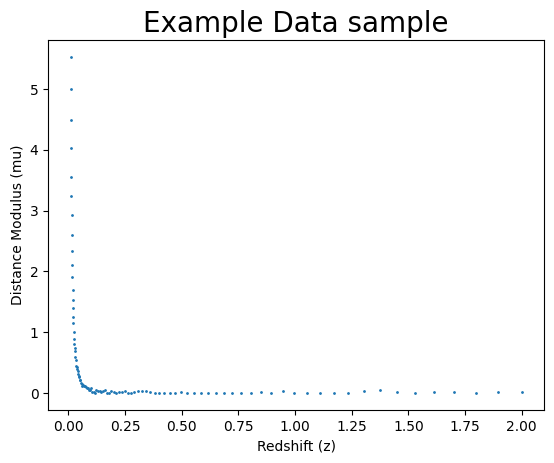

In [8]:
obs_no = np.random.randint(NUM_TRAIN)
flux_obs = 10**(-0.4*mu[obs_no, :])
mu_obs = mu[obs_no, :]
plt.scatter(z_obs, mu_obs, s=1)
# plt.scatter(z_obs, mu_noiseless[obs_no, :], color='red', label='True Signal')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
# plt.title(f"Obs: {obs_no} | H0: {h0[obs_no]:.2f}")
plt.title('Example Data sample', fontsize=20)
plt.show()

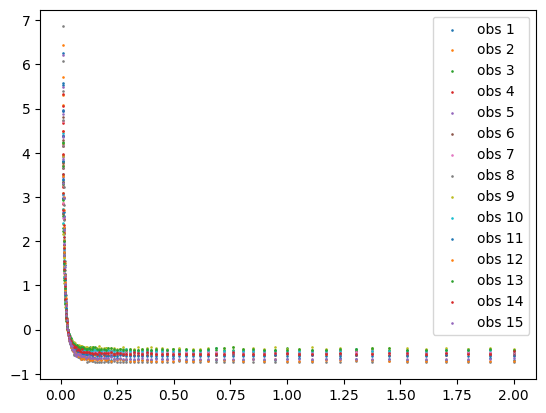

In [9]:
mu_zero_mean = mu - torch.mean(mu, axis=1)[:, None]
mu_zero_mean.shape

for i in range(15):
    plt.scatter(z_obs, mu_zero_mean[i, :], s=0.75, label=f'obs {i+1}')
plt.legend()
plt.show()

## Compression

In [10]:
h_theta = 0.5 * np.log(5) - 0.5 * np.log(1.0 + 0.5 * np.log(5))
ba_bounds = []
i_z_x = []

In [11]:
print("h_theta:", h_theta)

h_theta: 0.5095165178495286


In [12]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            # nn.Linear(input_size, 256),
            # # nn.BatchNorm1d(512),
            # nn.LeakyReLU(0.2),
            # # nn.Dropout(0.1),
            
            # nn.Linear(256, 128),
            # # nn.BatchNorm1d(32),
            # nn.LeakyReLU(0.2),
            
            nn.Linear(input_size, 64),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [97]:
model_encoder=Compressor()
model = IB(
    encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    # cond_prob_model=ConditionalKDE(1, 10),
    cond_prob_model=ConditionalNormalizingFlow(),
    beta = 1e-1,
    reg_weight=4e0,
    reg_type=0,
    optim_func=torch.optim.Adam,
    lr=1e-5
).to(device)

Epoch 1: Loss=-9.3295, log_q=-8.6928,, reg. loss=0.0099, beta * KL=0.6467
Epoch 10: Loss=-9.3881, log_q=-8.6947,, reg. loss=0.0103, beta * KL=0.7037
Epoch 20: Loss=-9.4577, log_q=-8.6969,, reg. loss=0.0108, beta * KL=0.7716


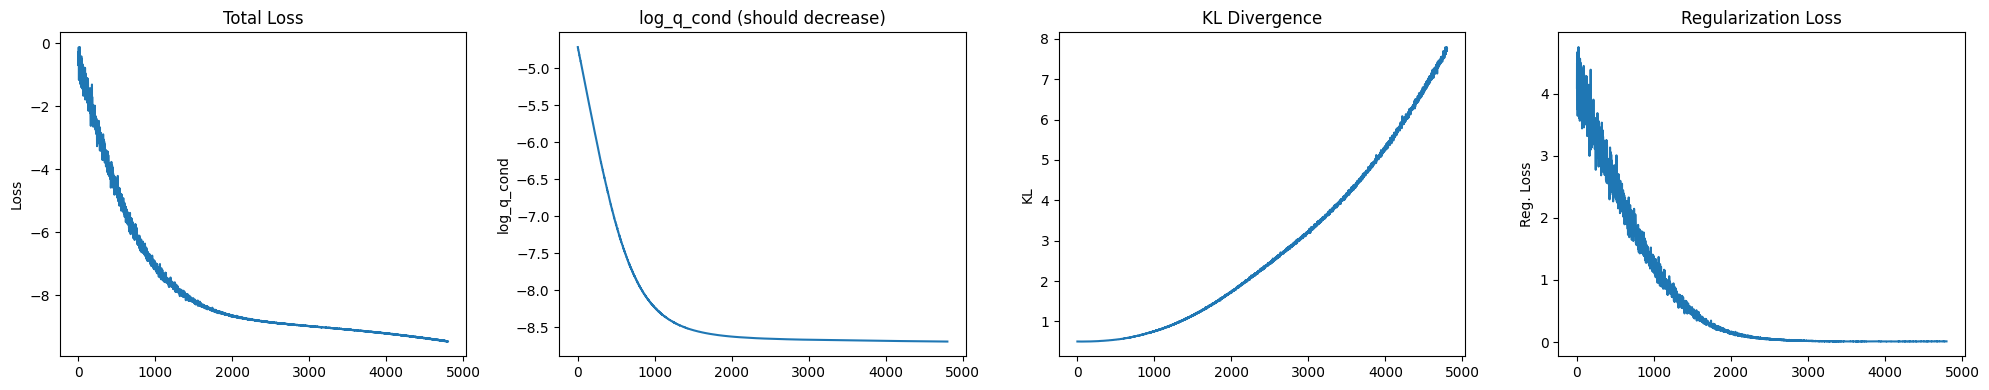

In [104]:
model.train(
    x_train=train_sims_data[:, :DATAPOINT_SIZE],
    y_train=train_sims_data[:, -1],
    nepochs=20,
    batch_size=512,
    print_losses=True
    )

assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

(array([2580.,  248.,  149.,  112.,   93.,   86.,   83.,   82.,   84.,
          83.]),
 array([-8.65000534, -8.26903057, -7.8880558 , -7.50708103, -7.12610626,
        -6.74513149, -6.36415672, -5.98318195, -5.60220718, -5.22123241,
        -4.84025764]),
 <BarContainer object of 10 artists>)

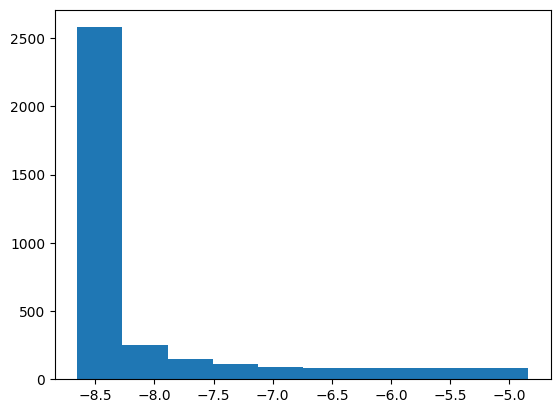

In [72]:
plt.hist(model.log_prob_losses)

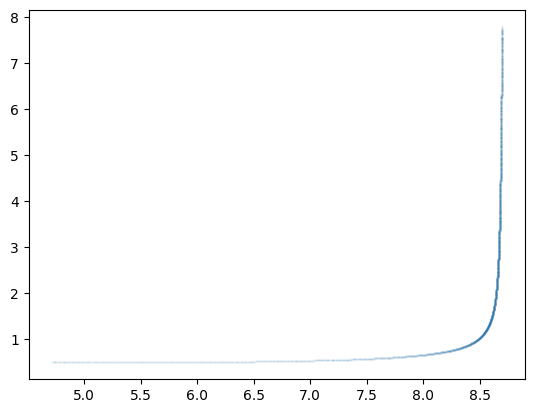

In [105]:
plt.scatter(-1 * np.array(model.log_prob_losses), np.array(model.kl_losses), alpha=0.1, s=1e-1)

In [63]:
ba_bounds = ba_bounds + model.log_prob_losses
i_z_x = i_z_x + model.kl_losses

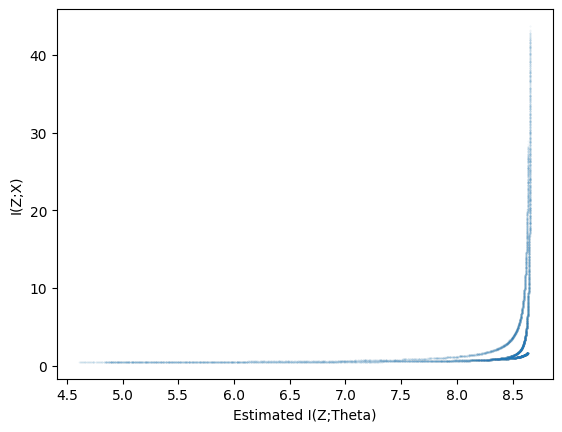

In [64]:
plt.scatter(-1*np.array(ba_bounds), i_z_x, alpha=0.1, s=1e-1)
plt.xlabel("Estimated I(Z;Theta)")
plt.ylabel("I(Z;X)")
# plt.xlim([0, 25])
# plt.ylim([0, 10])
# plt.xlim([4, 6])
# plt.ylim([0.4, 0.6])
plt.show()

Training new model iteration 1...
Epoch 1: Loss=-3.7952, log_q=-4.5829,, reg. loss=1.3126, beta * KL=0.5249
Epoch 10: Loss=-4.8649, log_q=-5.4678,, reg. loss=1.1087, beta * KL=0.5058
Epoch 20: Loss=-6.1514, log_q=-6.4740,, reg. loss=0.8670, beta * KL=0.5443
Epoch 30: Loss=-7.3040, log_q=-7.3345,, reg. loss=0.7188, beta * KL=0.6883
Epoch 40: Loss=-8.2582, log_q=-7.9005,, reg. loss=0.6027, beta * KL=0.9605
Epoch 50: Loss=-9.1099, log_q=-8.2253,, reg. loss=0.5023, beta * KL=1.3869
Epoch 60: Loss=-9.9851, log_q=-8.4024,, reg. loss=0.4339, beta * KL=2.0167
Epoch 70: Loss=-11.0920, log_q=-8.5028,, reg. loss=0.4232, beta * KL=3.0125
Epoch 80: Loss=-12.4849, log_q=-8.5583,, reg. loss=0.4098, beta * KL=4.3364
Epoch 90: Loss=-14.2224, log_q=-8.5910,, reg. loss=0.4218, beta * KL=6.0531
Epoch 100: Loss=-16.4813, log_q=-8.6123,, reg. loss=0.4816, beta * KL=8.3506
Epoch 110: Loss=-19.3749, log_q=-8.6259,, reg. loss=0.5594, beta * KL=11.3083
Epoch 120: Loss=-23.0863, log_q=-8.6350,, reg. loss=0.6798,

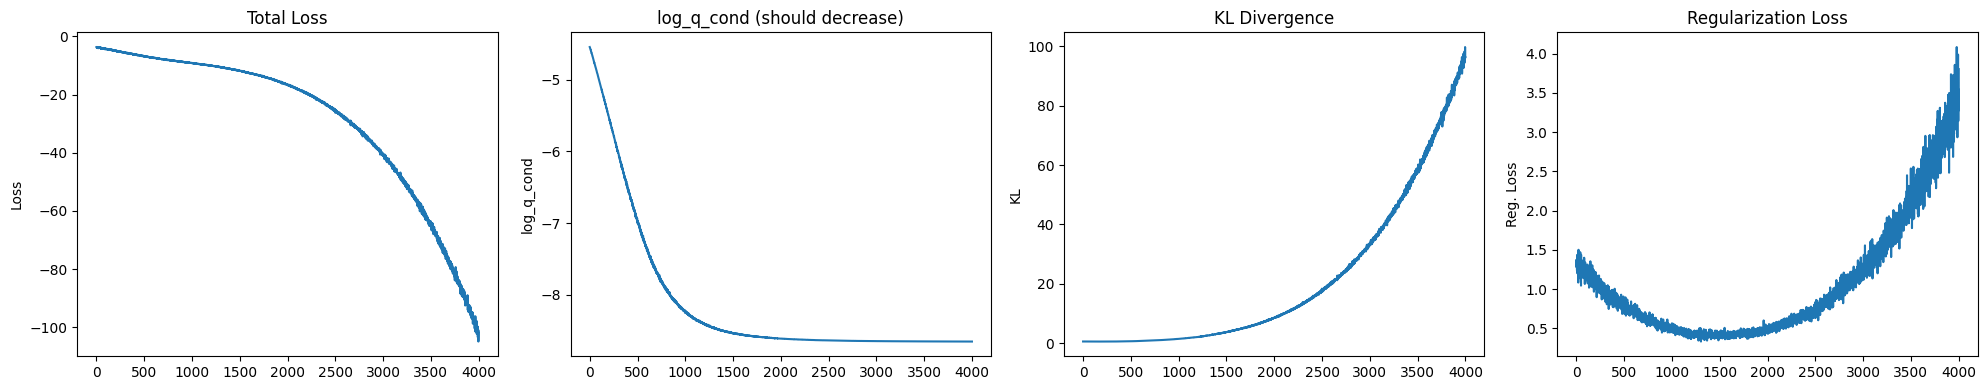

Training new model iteration 2...
Epoch 1: Loss=-3.8308, log_q=-4.4741,, reg. loss=1.1742, beta * KL=0.5308
Epoch 10: Loss=-4.8133, log_q=-5.2893,, reg. loss=1.0036, beta * KL=0.5277
Epoch 20: Loss=-5.9405, log_q=-6.2108,, reg. loss=0.8303, beta * KL=0.5600
Epoch 30: Loss=-6.9783, log_q=-7.0317,, reg. loss=0.6994, beta * KL=0.6460
Epoch 40: Loss=-7.8780, log_q=-7.6575,, reg. loss=0.5920, beta * KL=0.8125
Epoch 50: Loss=-8.6453, log_q=-8.0684,, reg. loss=0.5101, beta * KL=1.0869
Epoch 60: Loss=-9.3742, log_q=-8.3128,, reg. loss=0.4930, beta * KL=1.5544
Epoch 70: Loss=-10.2228, log_q=-8.4531,, reg. loss=0.4965, beta * KL=2.2663
Epoch 80: Loss=-11.2897, log_q=-8.5318,, reg. loss=0.5077, beta * KL=3.2656
Epoch 90: Loss=-12.6538, log_q=-8.5766,, reg. loss=0.5258, beta * KL=4.6031
Epoch 100: Loss=-14.3168, log_q=-8.6026,, reg. loss=0.5813, beta * KL=6.2955
Epoch 110: Loss=-16.4115, log_q=-8.6196,, reg. loss=0.6194, beta * KL=8.4113
Epoch 120: Loss=-19.1123, log_q=-8.6307,, reg. loss=0.7027, 

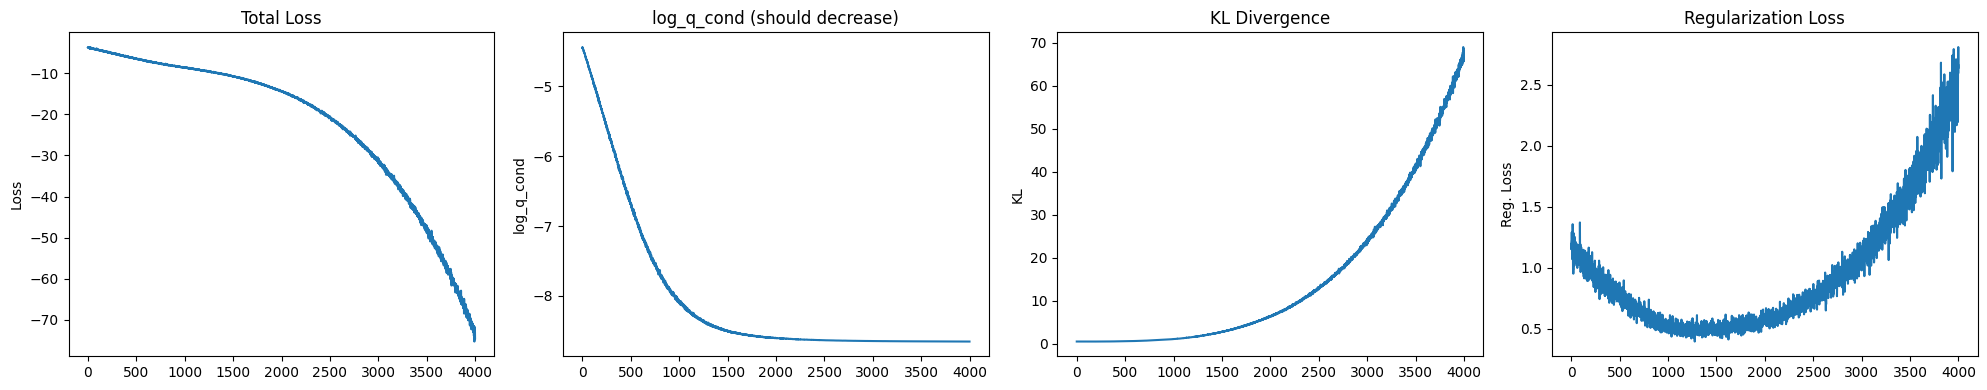

Training new model iteration 3...
Epoch 1: Loss=-4.2379, log_q=-4.6455,, reg. loss=0.9277, beta * KL=0.5201
Epoch 10: Loss=-5.2382, log_q=-5.4728,, reg. loss=0.7795, beta * KL=0.5449
Epoch 20: Loss=-6.3703, log_q=-6.3933,, reg. loss=0.6318, beta * KL=0.6087
Epoch 30: Loss=-7.4108, log_q=-7.1848,, reg. loss=0.5301, beta * KL=0.7561
Epoch 40: Loss=-8.3761, log_q=-7.7472,, reg. loss=0.4578, beta * KL=1.0867
Epoch 50: Loss=-9.3100, log_q=-8.1031,, reg. loss=0.4162, beta * KL=1.6231
Epoch 60: Loss=-10.3592, log_q=-8.3165,, reg. loss=0.4008, beta * KL=2.4436
Epoch 70: Loss=-11.5790, log_q=-8.4398,, reg. loss=0.4081, beta * KL=3.5473
Epoch 80: Loss=-13.1028, log_q=-8.5141,, reg. loss=0.4082, beta * KL=4.9970
Epoch 90: Loss=-14.9765, log_q=-8.5600,, reg. loss=0.4420, beta * KL=6.8586
Epoch 100: Loss=-17.3195, log_q=-8.5896,, reg. loss=0.4930, beta * KL=9.2230
Epoch 110: Loss=-20.2086, log_q=-8.6088,, reg. loss=0.5694, beta * KL=12.1692
Epoch 120: Loss=-23.7175, log_q=-8.6218,, reg. loss=0.6705

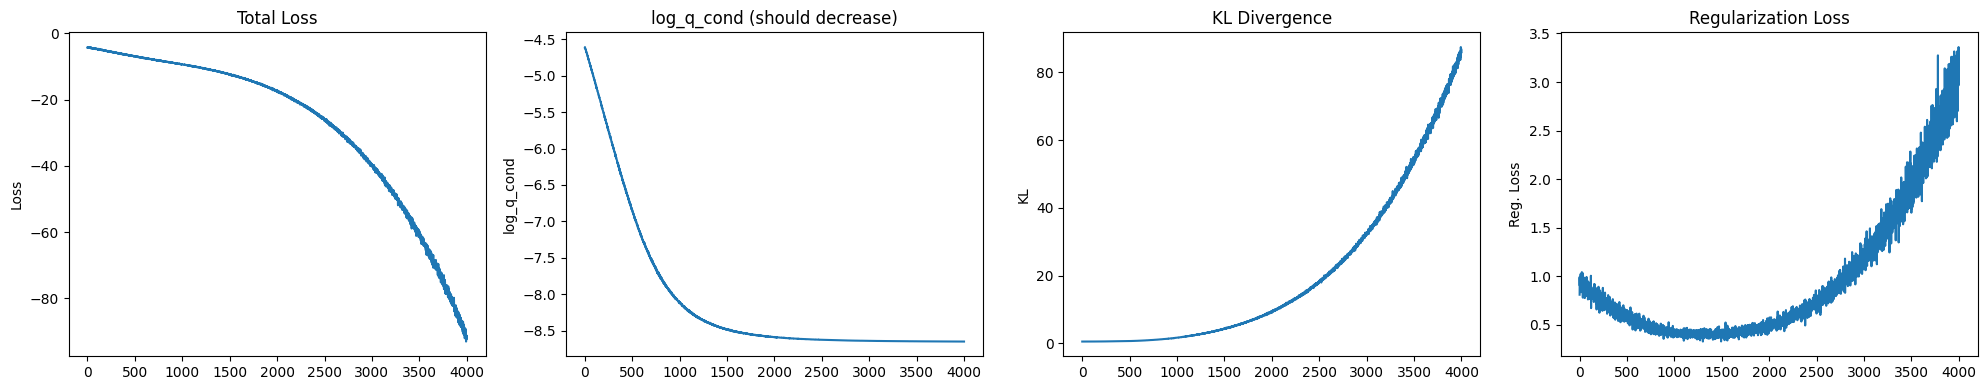

Training new model iteration 4...
Epoch 1: Loss=-3.7576, log_q=-4.2073,, reg. loss=0.9537, beta * KL=0.5039
Epoch 10: Loss=-4.7479, log_q=-4.9971,, reg. loss=0.7645, beta * KL=0.5153
Epoch 20: Loss=-5.9588, log_q=-5.9998,, reg. loss=0.5974, beta * KL=0.5563
Epoch 30: Loss=-7.0852, log_q=-6.9212,, reg. loss=0.4645, beta * KL=0.6286
Epoch 40: Loss=-8.0597, log_q=-7.6307,, reg. loss=0.3482, beta * KL=0.7771
Epoch 50: Loss=-8.8861, log_q=-8.0800,, reg. loss=0.2475, beta * KL=1.0536
Epoch 60: Loss=-9.6488, log_q=-8.3231,, reg. loss=0.1956, beta * KL=1.5212
Epoch 70: Loss=-10.4767, log_q=-8.4518,, reg. loss=0.1749, beta * KL=2.1998
Epoch 80: Loss=-11.4606, log_q=-8.5238,, reg. loss=0.1684, beta * KL=3.1053
Epoch 90: Loss=-12.6220, log_q=-8.5664,, reg. loss=0.1794, beta * KL=4.2350
Epoch 100: Loss=-14.0540, log_q=-8.5939,, reg. loss=0.2068, beta * KL=5.6669
Epoch 110: Loss=-15.7993, log_q=-8.6117,, reg. loss=0.2510, beta * KL=7.4385
Epoch 120: Loss=-17.9043, log_q=-8.6238,, reg. loss=0.3224, 

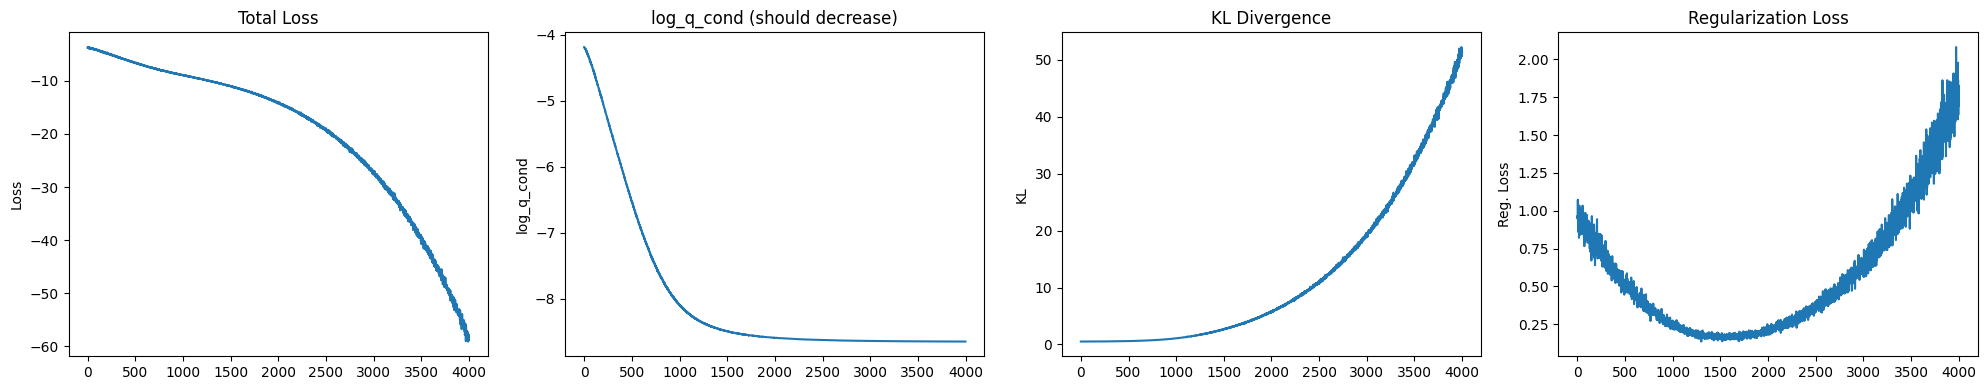

Training new model iteration 5...
Epoch 1: Loss=-4.8040, log_q=-5.3055,, reg. loss=1.0046, beta * KL=0.5031
Epoch 10: Loss=-5.7447, log_q=-6.1396,, reg. loss=0.8998, beta * KL=0.5048
Epoch 20: Loss=-6.7263, log_q=-6.9651,, reg. loss=0.7579, beta * KL=0.5191
Epoch 30: Loss=-7.5421, log_q=-7.6068,, reg. loss=0.6212, beta * KL=0.5565
Epoch 40: Loss=-8.2041, log_q=-8.0284,, reg. loss=0.4746, beta * KL=0.6504
Epoch 50: Loss=-8.7987, log_q=-8.2681,, reg. loss=0.3364, beta * KL=0.8669
Epoch 60: Loss=-9.3888, log_q=-8.3997,, reg. loss=0.2607, beta * KL=1.2498
Epoch 70: Loss=-10.0977, log_q=-8.4777,, reg. loss=0.2133, beta * KL=1.8334
Epoch 80: Loss=-10.9847, log_q=-8.5295,, reg. loss=0.1863, beta * KL=2.6416
Epoch 90: Loss=-12.0815, log_q=-8.5648,, reg. loss=0.1959, beta * KL=3.7126
Epoch 100: Loss=-13.4693, log_q=-8.5897,, reg. loss=0.2246, beta * KL=5.1043
Epoch 110: Loss=-15.2376, log_q=-8.6075,, reg. loss=0.2720, beta * KL=6.9021
Epoch 120: Loss=-17.4729, log_q=-8.6202,, reg. loss=0.3400, 

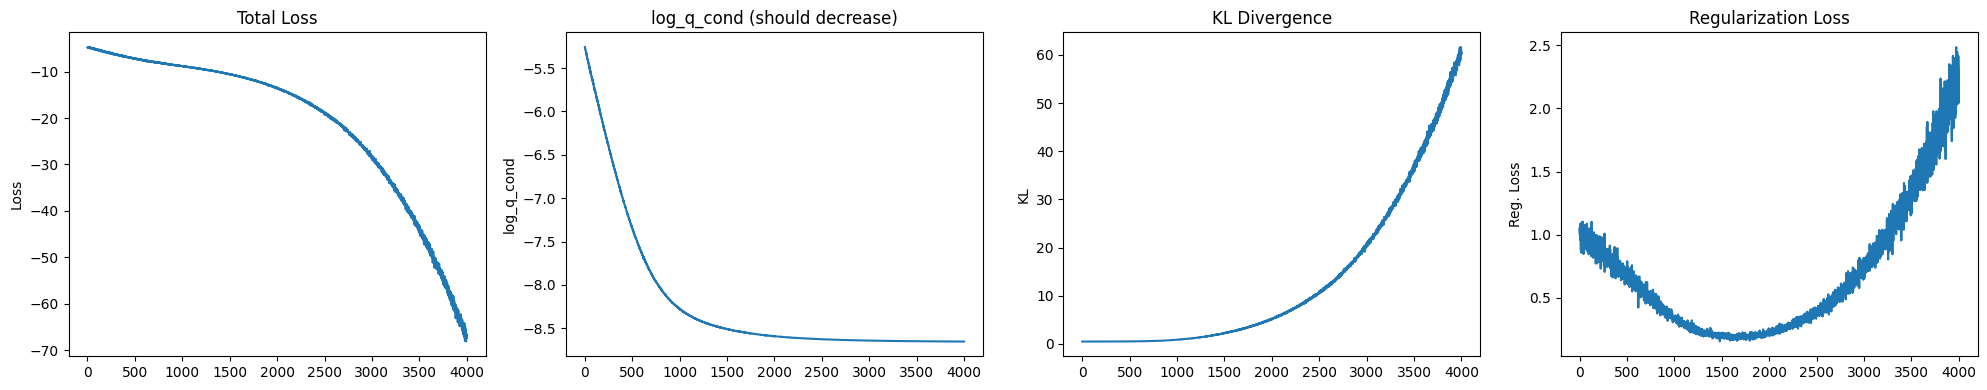

Training new model iteration 6...
Epoch 1: Loss=-4.1551, log_q=-4.7383,, reg. loss=1.1027, beta * KL=0.5195
Epoch 10: Loss=-5.0049, log_q=-5.4535,, reg. loss=0.9601, beta * KL=0.5115
Epoch 20: Loss=-6.0044, log_q=-6.2754,, reg. loss=0.7908, beta * KL=0.5198
Epoch 30: Loss=-6.9437, log_q=-7.0501,, reg. loss=0.6526, beta * KL=0.5462
Epoch 40: Loss=-7.7449, log_q=-7.6698,, reg. loss=0.5170, beta * KL=0.5921
Epoch 50: Loss=-8.3823, log_q=-8.0718,, reg. loss=0.3745, beta * KL=0.6850
Epoch 60: Loss=-8.8734, log_q=-8.3025,, reg. loss=0.2628, beta * KL=0.8337
Epoch 70: Loss=-9.2969, log_q=-8.4303,, reg. loss=0.1843, beta * KL=1.0509
Epoch 80: Loss=-9.7216, log_q=-8.5017,, reg. loss=0.1372, beta * KL=1.3571
Epoch 90: Loss=-10.2426, log_q=-8.5452,, reg. loss=0.1162, beta * KL=1.8137
Epoch 100: Loss=-10.8636, log_q=-8.5744,, reg. loss=0.1015, beta * KL=2.3908
Epoch 110: Loss=-11.6006, log_q=-8.5955,, reg. loss=0.1028, beta * KL=3.1079
Epoch 120: Loss=-12.4770, log_q=-8.6110,, reg. loss=0.1180, be

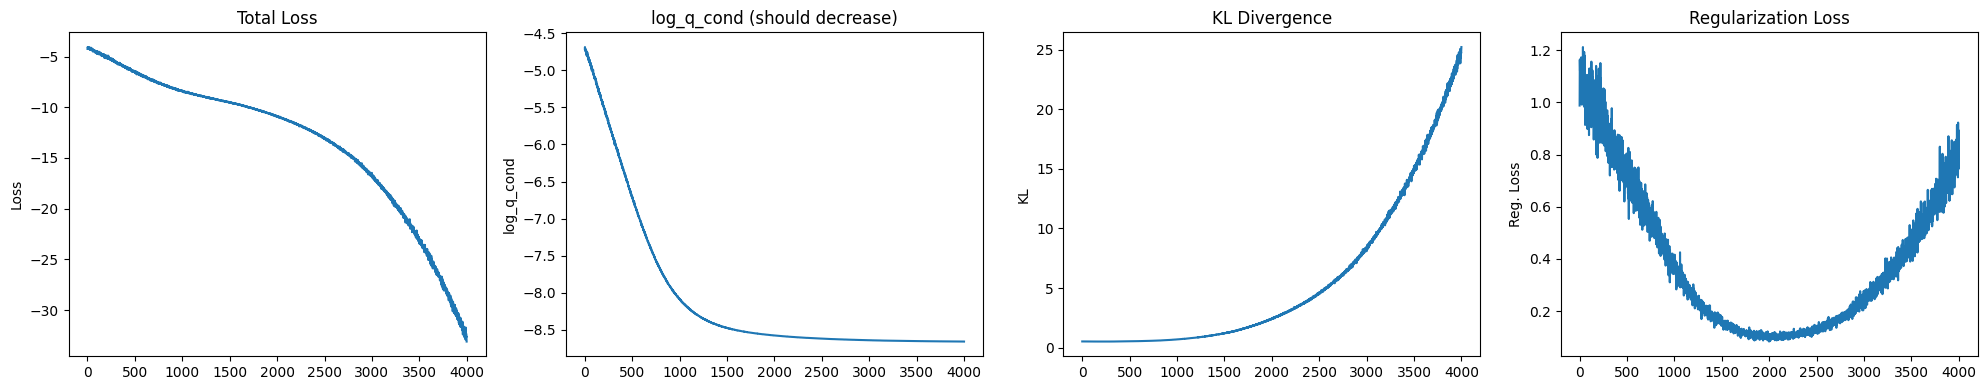

Training new model iteration 7...
Epoch 1: Loss=-4.4194, log_q=-4.9053,, reg. loss=0.9911, beta * KL=0.5053
Epoch 10: Loss=-5.2761, log_q=-5.6676,, reg. loss=0.8974, beta * KL=0.5060
Epoch 20: Loss=-6.2695, log_q=-6.4982,, reg. loss=0.7548, beta * KL=0.5262
Epoch 30: Loss=-7.2187, log_q=-7.2399,, reg. loss=0.6281, beta * KL=0.6069
Epoch 40: Loss=-8.0647, log_q=-7.7857,, reg. loss=0.5150, beta * KL=0.7940
Epoch 50: Loss=-8.8272, log_q=-8.1266,, reg. loss=0.4347, beta * KL=1.1352
Epoch 60: Loss=-9.6442, log_q=-8.3256,, reg. loss=0.3602, beta * KL=1.6788
Epoch 70: Loss=-10.5636, log_q=-8.4402,, reg. loss=0.3040, beta * KL=2.4273
Epoch 80: Loss=-11.7394, log_q=-8.5122,, reg. loss=0.2836, beta * KL=3.5109
Epoch 90: Loss=-13.2134, log_q=-8.5565,, reg. loss=0.2943, beta * KL=4.9512
Epoch 100: Loss=-15.0420, log_q=-8.5851,, reg. loss=0.3269, beta * KL=6.7838
Epoch 110: Loss=-17.3486, log_q=-8.6046,, reg. loss=0.3810, beta * KL=9.1250
Epoch 120: Loss=-20.2041, log_q=-8.6182,, reg. loss=0.4629, 

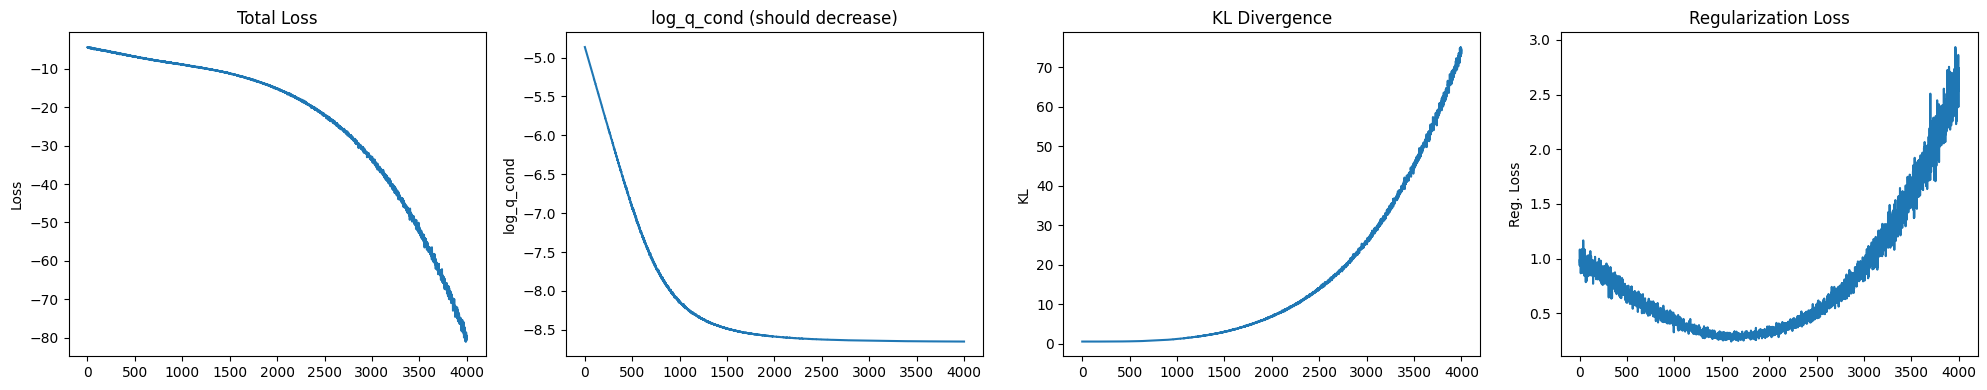

Training new model iteration 8...
Epoch 1: Loss=-4.2090, log_q=-4.6330,, reg. loss=0.9261, beta * KL=0.5022
Epoch 10: Loss=-5.1722, log_q=-5.4267,, reg. loss=0.7727, beta * KL=0.5182
Epoch 20: Loss=-6.2336, log_q=-6.2986,, reg. loss=0.6345, beta * KL=0.5696
Epoch 30: Loss=-7.3009, log_q=-7.1107,, reg. loss=0.5314, beta * KL=0.7215
Epoch 40: Loss=-8.2739, log_q=-7.7140,, reg. loss=0.4654, beta * KL=1.0253
Epoch 50: Loss=-9.2456, log_q=-8.1048,, reg. loss=0.4136, beta * KL=1.5544
Epoch 60: Loss=-10.2740, log_q=-8.3312,, reg. loss=0.4151, beta * KL=2.3580
Epoch 70: Loss=-11.5285, log_q=-8.4575,, reg. loss=0.4220, beta * KL=3.4931
Epoch 80: Loss=-13.1440, log_q=-8.5291,, reg. loss=0.4450, beta * KL=5.0598
Epoch 90: Loss=-15.1539, log_q=-8.5714,, reg. loss=0.4798, beta * KL=7.0623
Epoch 100: Loss=-17.6289, log_q=-8.5970,, reg. loss=0.5488, beta * KL=9.5807
Epoch 110: Loss=-20.6730, log_q=-8.6135,, reg. loss=0.6380, beta * KL=12.6975
Epoch 120: Loss=-24.3779, log_q=-8.6244,, reg. loss=0.7578

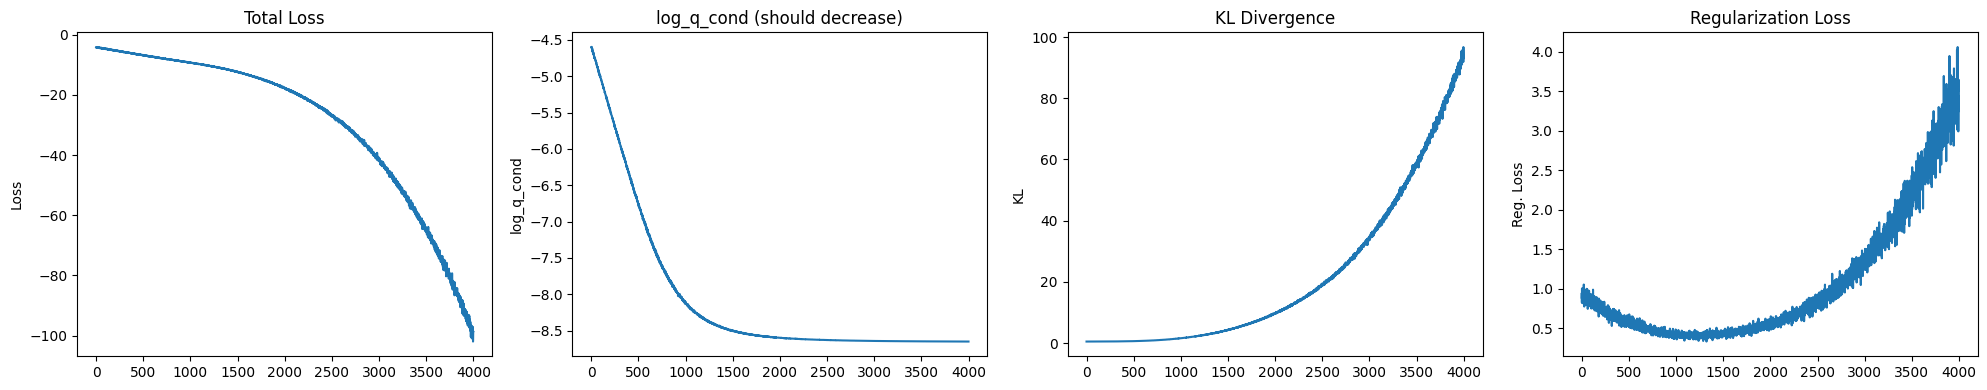

Training new model iteration 9...
Epoch 1: Loss=-4.2016, log_q=-4.5026,, reg. loss=0.8086, beta * KL=0.5077
Epoch 10: Loss=-5.1614, log_q=-5.3341,, reg. loss=0.7005, beta * KL=0.5277
Epoch 20: Loss=-6.2808, log_q=-6.3056,, reg. loss=0.5875, beta * KL=0.5627
Epoch 30: Loss=-7.3073, log_q=-7.1637,, reg. loss=0.4796, beta * KL=0.6232
Epoch 40: Loss=-8.1877, log_q=-7.7930,, reg. loss=0.3691, beta * KL=0.7638
Epoch 50: Loss=-8.9222, log_q=-8.1616,, reg. loss=0.2793, beta * KL=1.0400
Epoch 60: Loss=-9.5984, log_q=-8.3518,, reg. loss=0.2202, beta * KL=1.4669
Epoch 70: Loss=-10.3198, log_q=-8.4553,, reg. loss=0.1872, beta * KL=2.0518
Epoch 80: Loss=-11.1610, log_q=-8.5163,, reg. loss=0.1789, beta * KL=2.8236
Epoch 90: Loss=-12.2181, log_q=-8.5551,, reg. loss=0.1793, beta * KL=3.8423
Epoch 100: Loss=-13.5536, log_q=-8.5812,, reg. loss=0.2008, beta * KL=5.1731
Epoch 110: Loss=-15.2224, log_q=-8.5998,, reg. loss=0.2418, beta * KL=6.8644
Epoch 120: Loss=-17.3290, log_q=-8.6134,, reg. loss=0.3001, 

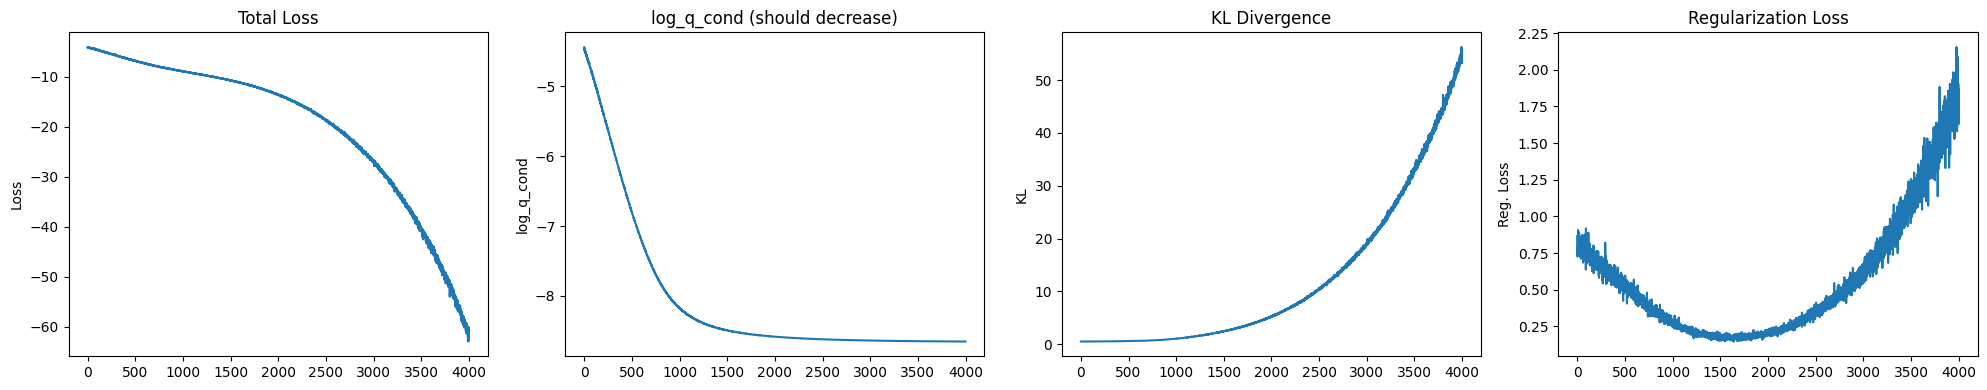

Training new model iteration 10...
Epoch 1: Loss=-4.1072, log_q=-4.4342,, reg. loss=0.8361, beta * KL=0.5091
Epoch 10: Loss=-5.0497, log_q=-5.1940,, reg. loss=0.6872, beta * KL=0.5429
Epoch 20: Loss=-6.2323, log_q=-6.1327,, reg. loss=0.5443, beta * KL=0.6439
Epoch 30: Loss=-7.4348, log_q=-6.9985,, reg. loss=0.4348, beta * KL=0.8710
Epoch 40: Loss=-8.5748, log_q=-7.6628,, reg. loss=0.3601, beta * KL=1.2721
Epoch 50: Loss=-9.6467, log_q=-8.0796,, reg. loss=0.3231, beta * KL=1.8901
Epoch 60: Loss=-10.7444, log_q=-8.3147,, reg. loss=0.3065, beta * KL=2.7362
Epoch 70: Loss=-12.0138, log_q=-8.4456,, reg. loss=0.2971, beta * KL=3.8653
Epoch 80: Loss=-13.5267, log_q=-8.5186,, reg. loss=0.3179, beta * KL=5.3261
Epoch 90: Loss=-15.4041, log_q=-8.5634,, reg. loss=0.3513, beta * KL=7.1920
Epoch 100: Loss=-17.7802, log_q=-8.5919,, reg. loss=0.4244, beta * KL=9.6128
Epoch 110: Loss=-20.7139, log_q=-8.6105,, reg. loss=0.5081, beta * KL=12.6116
Epoch 120: Loss=-24.2805, log_q=-8.6227,, reg. loss=0.616

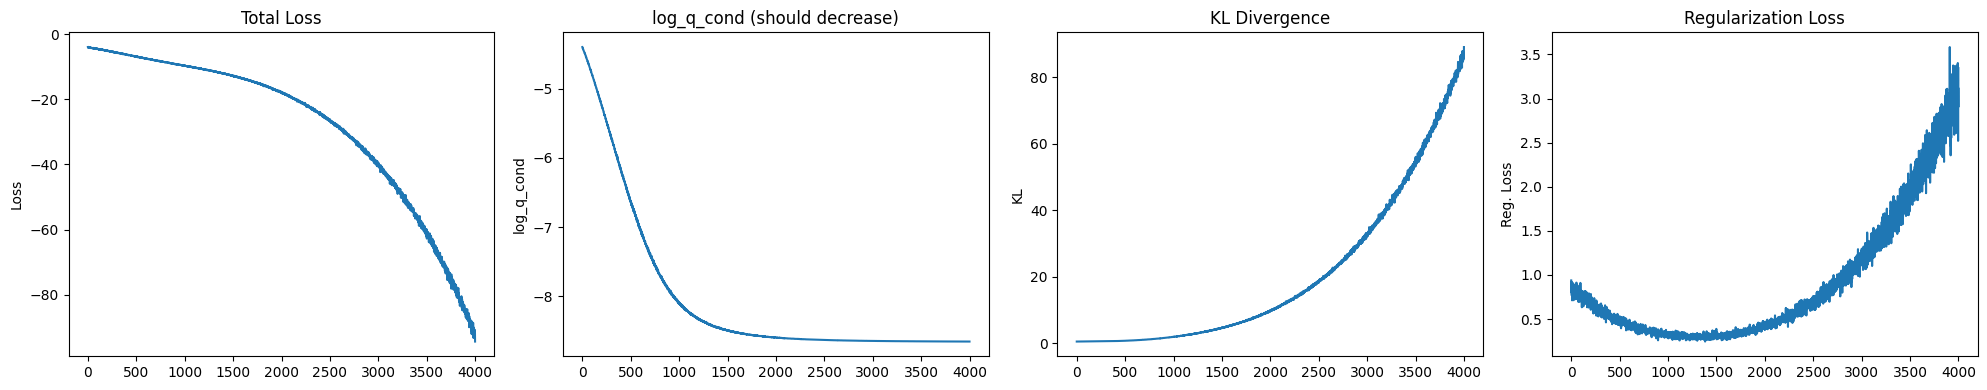

Training new model iteration 11...
Epoch 1: Loss=-3.9476, log_q=-4.4852,, reg. loss=1.0554, beta * KL=0.5178
Epoch 10: Loss=-4.9986, log_q=-5.3768,, reg. loss=0.9012, beta * KL=0.5229
Epoch 20: Loss=-6.1713, log_q=-6.3758,, reg. loss=0.7536, beta * KL=0.5492
Epoch 30: Loss=-7.1844, log_q=-7.2117,, reg. loss=0.6300, beta * KL=0.6027
Epoch 40: Loss=-8.0433, log_q=-7.8095,, reg. loss=0.4891, beta * KL=0.7229
Epoch 50: Loss=-8.7008, log_q=-8.1531,, reg. loss=0.4051, beta * KL=0.9528
Epoch 60: Loss=-9.3414, log_q=-8.3416,, reg. loss=0.3512, beta * KL=1.3510
Epoch 70: Loss=-10.0527, log_q=-8.4450,, reg. loss=0.3188, beta * KL=1.9266
Epoch 80: Loss=-10.8778, log_q=-8.5073,, reg. loss=0.3136, beta * KL=2.6841
Epoch 90: Loss=-11.8745, log_q=-8.5473,, reg. loss=0.3103, beta * KL=3.6374
Epoch 100: Loss=-13.1162, log_q=-8.5750,, reg. loss=0.3124, beta * KL=4.8536
Epoch 110: Loss=-14.6362, log_q=-8.5947,, reg. loss=0.3384, beta * KL=6.3799
Epoch 120: Loss=-16.5313, log_q=-8.6090,, reg. loss=0.3776,

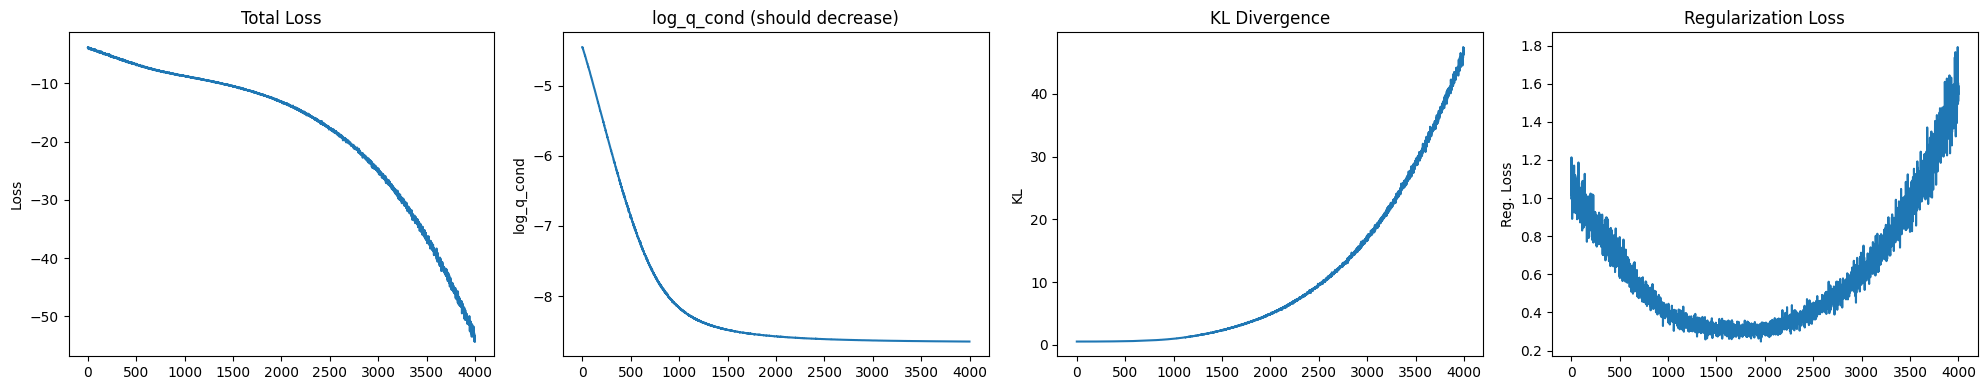

Training new model iteration 12...
Epoch 1: Loss=-4.4853, log_q=-5.0169,, reg. loss=1.0380, beta * KL=0.5065
Epoch 10: Loss=-5.5133, log_q=-5.8696,, reg. loss=0.8678, beta * KL=0.5116
Epoch 20: Loss=-6.5587, log_q=-6.7593,, reg. loss=0.7518, beta * KL=0.5512
Epoch 30: Loss=-7.4622, log_q=-7.4700,, reg. loss=0.6542, beta * KL=0.6463
Epoch 40: Loss=-8.2945, log_q=-7.9594,, reg. loss=0.5136, beta * KL=0.8487
Epoch 50: Loss=-8.9649, log_q=-8.2393,, reg. loss=0.4483, beta * KL=1.1739
Epoch 60: Loss=-9.6828, log_q=-8.4013,, reg. loss=0.3920, beta * KL=1.6735
Epoch 70: Loss=-10.5700, log_q=-8.4930,, reg. loss=0.3819, beta * KL=2.4589
Epoch 80: Loss=-11.7061, log_q=-8.5477,, reg. loss=0.3688, beta * KL=3.5271
Epoch 90: Loss=-13.1468, log_q=-8.5820,, reg. loss=0.3962, beta * KL=4.9609
Epoch 100: Loss=-14.9726, log_q=-8.6050,, reg. loss=0.4298, beta * KL=6.7974
Epoch 110: Loss=-17.2000, log_q=-8.6200,, reg. loss=0.4828, beta * KL=9.0628
Epoch 120: Loss=-19.9237, log_q=-8.6302,, reg. loss=0.5663,

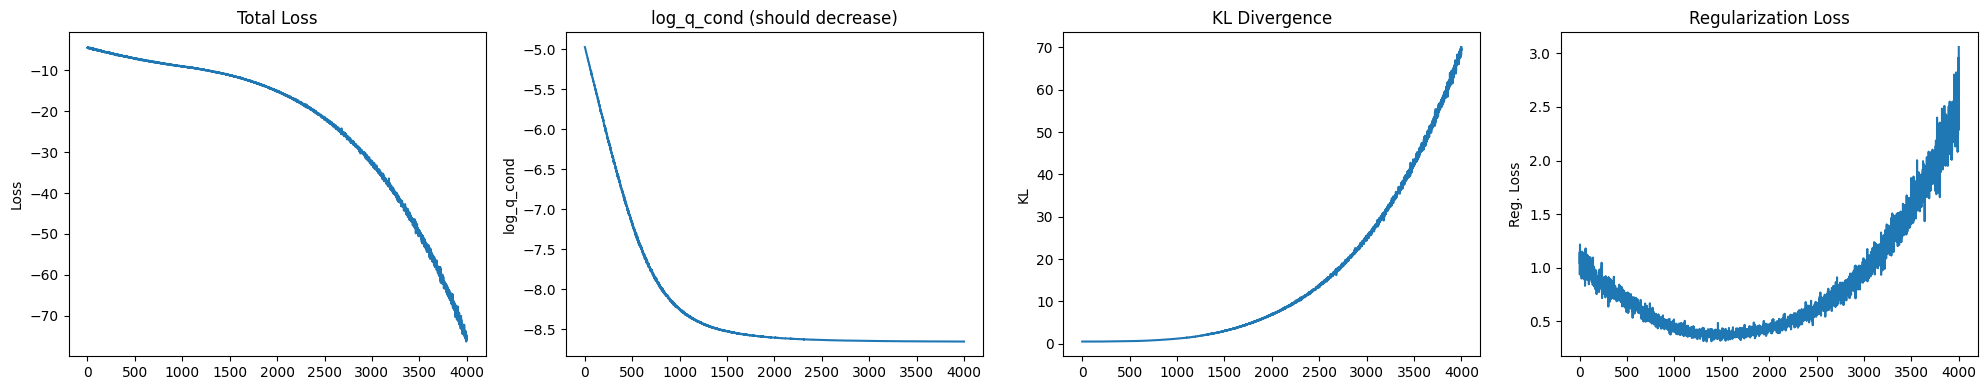

Training new model iteration 13...
Epoch 1: Loss=-4.1633, log_q=-4.7741,, reg. loss=1.1475, beta * KL=0.5367
Epoch 10: Loss=-5.1872, log_q=-5.6284,, reg. loss=0.9742, beta * KL=0.5331
Epoch 20: Loss=-6.2574, log_q=-6.5313,, reg. loss=0.8328, beta * KL=0.5589
Epoch 30: Loss=-7.2417, log_q=-7.3083,, reg. loss=0.7058, beta * KL=0.6393
Epoch 40: Loss=-8.0815, log_q=-7.8520,, reg. loss=0.5892, beta * KL=0.8187
Epoch 50: Loss=-8.7963, log_q=-8.1777,, reg. loss=0.5178, beta * KL=1.1364
Epoch 60: Loss=-9.5143, log_q=-8.3653,, reg. loss=0.4832, beta * KL=1.6321
Epoch 70: Loss=-10.3417, log_q=-8.4741,, reg. loss=0.4617, beta * KL=2.3293
Epoch 80: Loss=-11.3495, log_q=-8.5369,, reg. loss=0.4875, beta * KL=3.3001
Epoch 90: Loss=-12.6220, log_q=-8.5763,, reg. loss=0.5390, beta * KL=4.5847
Epoch 100: Loss=-14.3056, log_q=-8.6015,, reg. loss=0.5940, beta * KL=6.2981
Epoch 110: Loss=-16.4838, log_q=-8.6188,, reg. loss=0.6557, beta * KL=8.5207
Epoch 120: Loss=-19.2080, log_q=-8.6297,, reg. loss=0.7520,

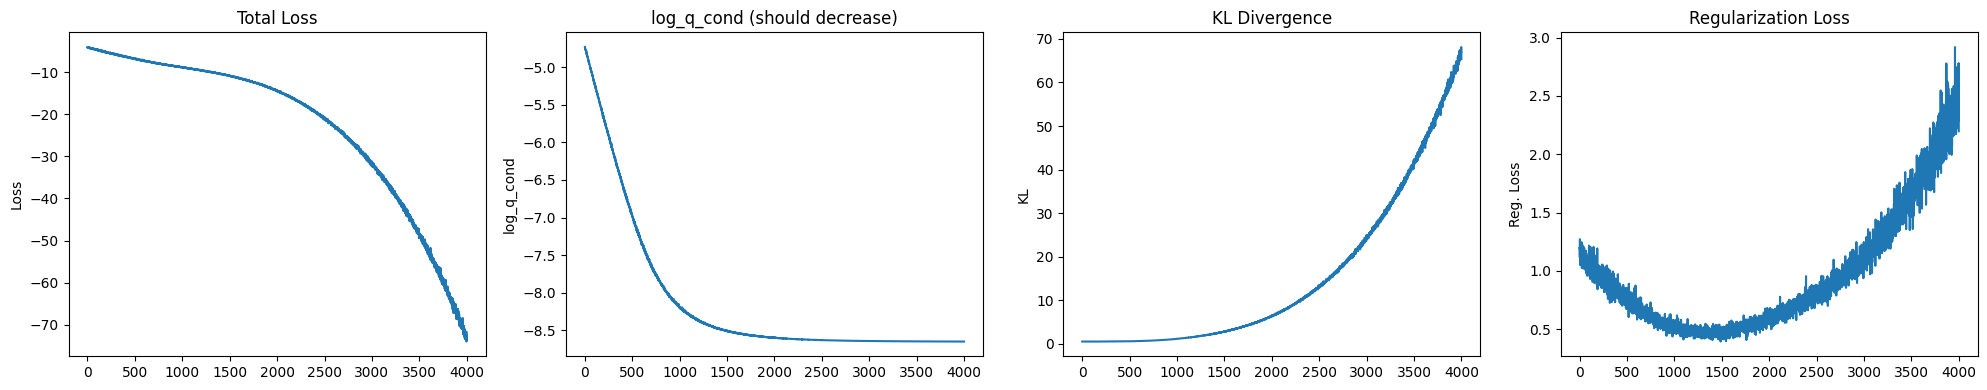

Training new model iteration 14...
Epoch 1: Loss=-4.9027, log_q=-5.0683,, reg. loss=0.7821, beta * KL=0.6165
Epoch 10: Loss=-5.9580, log_q=-5.9143,, reg. loss=0.6563, beta * KL=0.7001
Epoch 20: Loss=-7.1534, log_q=-6.7914,, reg. loss=0.5559, beta * KL=0.9180
Epoch 30: Loss=-8.3533, log_q=-7.5057,, reg. loss=0.4855, beta * KL=1.3331
Epoch 40: Loss=-9.5954, log_q=-8.0120,, reg. loss=0.4215, beta * KL=2.0049
Epoch 50: Loss=-10.8836, log_q=-8.3040,, reg. loss=0.3974, beta * KL=2.9770
Epoch 60: Loss=-12.4119, log_q=-8.4610,, reg. loss=0.3897, beta * KL=4.3405
Epoch 70: Loss=-14.3909, log_q=-8.5425,, reg. loss=0.4224, beta * KL=6.2708
Epoch 80: Loss=-16.8534, log_q=-8.5863,, reg. loss=0.4790, beta * KL=8.7461
Epoch 90: Loss=-20.0720, log_q=-8.6117,, reg. loss=0.5515, beta * KL=12.0118
Epoch 100: Loss=-24.0456, log_q=-8.6259,, reg. loss=0.6711, beta * KL=16.0907
Epoch 110: Loss=-28.9207, log_q=-8.6346,, reg. loss=0.8321, beta * KL=21.1182
Epoch 120: Loss=-34.8882, log_q=-8.6401,, reg. loss=1.

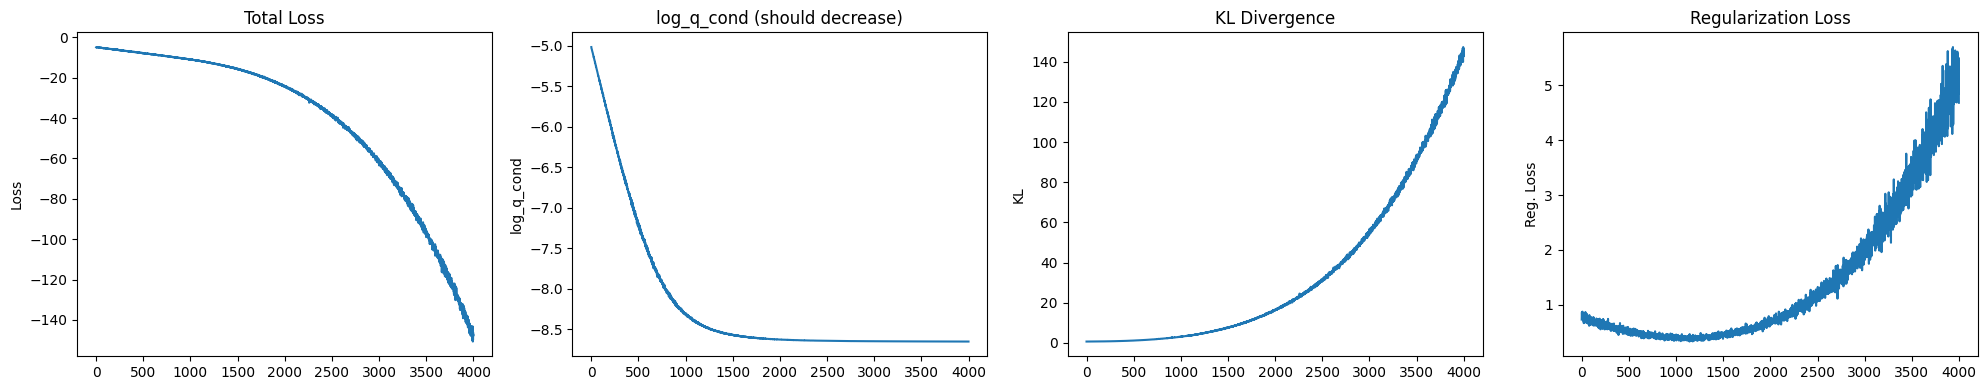

Training new model iteration 15...
Epoch 1: Loss=-4.1602, log_q=-4.6355,, reg. loss=0.9854, beta * KL=0.5101
Epoch 10: Loss=-5.1741, log_q=-5.4708,, reg. loss=0.8127, beta * KL=0.5161
Epoch 20: Loss=-6.2606, log_q=-6.3908,, reg. loss=0.6726, beta * KL=0.5424
Epoch 30: Loss=-7.2454, log_q=-7.1818,, reg. loss=0.5375, beta * KL=0.6011
Epoch 40: Loss=-8.0639, log_q=-7.7539,, reg. loss=0.4107, beta * KL=0.7207
Epoch 50: Loss=-8.7055, log_q=-8.1043,, reg. loss=0.3330, beta * KL=0.9342
Epoch 60: Loss=-9.2971, log_q=-8.3037,, reg. loss=0.2671, beta * KL=1.2605
Epoch 70: Loss=-9.9377, log_q=-8.4205,, reg. loss=0.2421, beta * KL=1.7593
Epoch 80: Loss=-10.6837, log_q=-8.4932,, reg. loss=0.2364, beta * KL=2.4269
Epoch 90: Loss=-11.7199, log_q=-8.5434,, reg. loss=0.2483, beta * KL=3.4249
Epoch 100: Loss=-13.0429, log_q=-8.5770,, reg. loss=0.2756, beta * KL=4.7415
Epoch 110: Loss=-14.7330, log_q=-8.6003,, reg. loss=0.3183, beta * KL=6.4510
Epoch 120: Loss=-16.9425, log_q=-8.6166,, reg. loss=0.3937, 

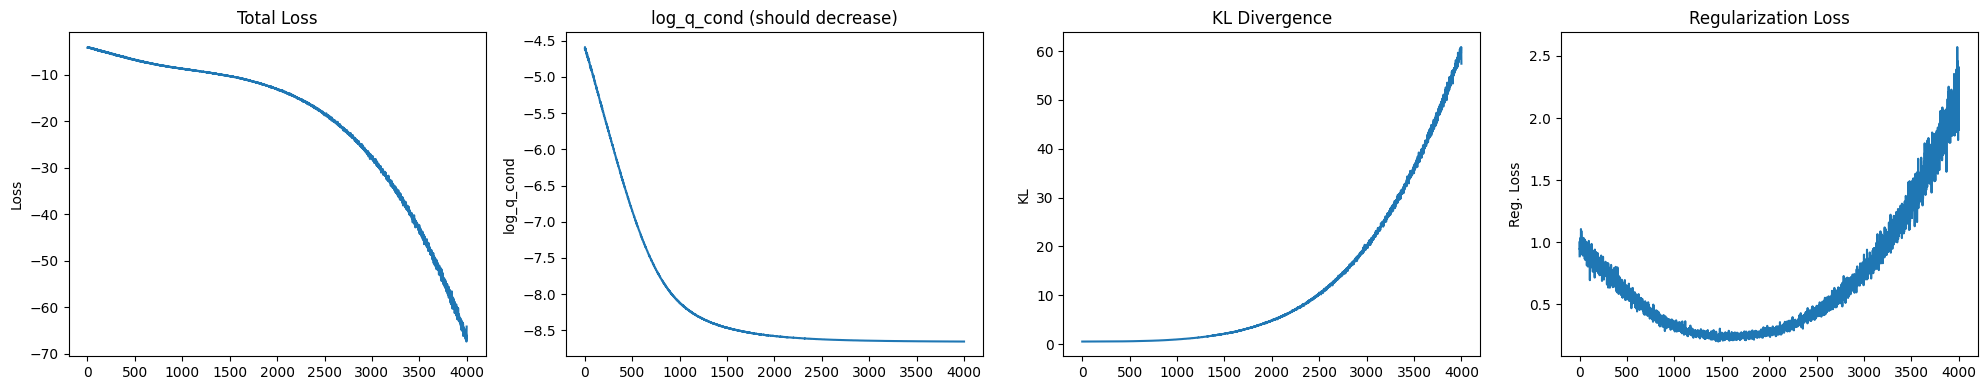

Training new model iteration 16...
Epoch 1: Loss=-4.0246, log_q=-4.7005,, reg. loss=1.1975, beta * KL=0.5216
Epoch 10: Loss=-5.0289, log_q=-5.4782,, reg. loss=0.9862, beta * KL=0.5368
Epoch 20: Loss=-6.1986, log_q=-6.3359,, reg. loss=0.7631, beta * KL=0.6258
Epoch 30: Loss=-7.3663, log_q=-7.1294,, reg. loss=0.5874, beta * KL=0.8243
Epoch 40: Loss=-8.3965, log_q=-7.7334,, reg. loss=0.4758, beta * KL=1.1388
Epoch 50: Loss=-9.3910, log_q=-8.1329,, reg. loss=0.3680, beta * KL=1.6260
Epoch 60: Loss=-10.3840, log_q=-8.3572,, reg. loss=0.2951, beta * KL=2.3219
Epoch 70: Loss=-11.4337, log_q=-8.4804,, reg. loss=0.2439, beta * KL=3.1972
Epoch 80: Loss=-12.6079, log_q=-8.5460,, reg. loss=0.2298, beta * KL=4.2917
Epoch 90: Loss=-13.9745, log_q=-8.5833,, reg. loss=0.2392, beta * KL=5.6305
Epoch 100: Loss=-15.6080, log_q=-8.6058,, reg. loss=0.2613, beta * KL=7.2634
Epoch 110: Loss=-17.5640, log_q=-8.6206,, reg. loss=0.3043, beta * KL=9.2477
Epoch 120: Loss=-19.9149, log_q=-8.6304,, reg. loss=0.3744

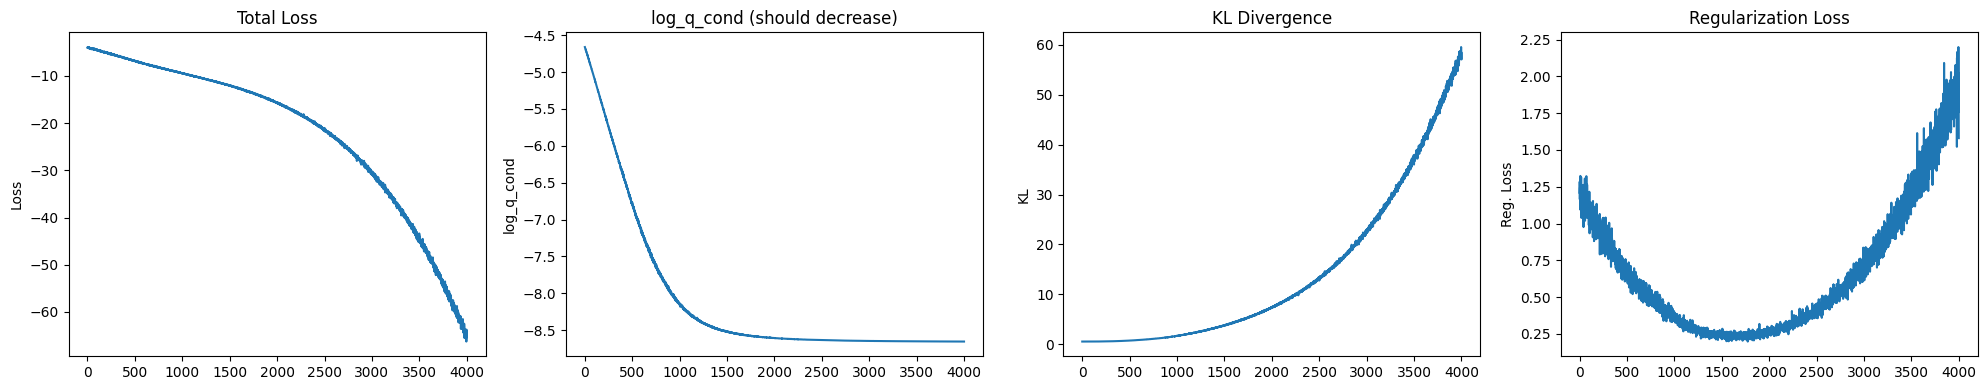

Training new model iteration 17...
Epoch 1: Loss=-3.4903, log_q=-4.3995,, reg. loss=1.4461, beta * KL=0.5370
Epoch 10: Loss=-4.5160, log_q=-5.1662,, reg. loss=1.1591, beta * KL=0.5089
Epoch 20: Loss=-5.6770, log_q=-6.1534,, reg. loss=0.9840, beta * KL=0.5075
Epoch 30: Loss=-6.8547, log_q=-7.0639,, reg. loss=0.7589, beta * KL=0.5497
Epoch 40: Loss=-7.7850, log_q=-7.7410,, reg. loss=0.6096, beta * KL=0.6535
Epoch 50: Loss=-8.4960, log_q=-8.1352,, reg. loss=0.4993, beta * KL=0.8601
Epoch 60: Loss=-9.1648, log_q=-8.3476,, reg. loss=0.3951, beta * KL=1.2123
Epoch 70: Loss=-9.8537, log_q=-8.4611,, reg. loss=0.3442, beta * KL=1.7368
Epoch 80: Loss=-10.6806, log_q=-8.5257,, reg. loss=0.3110, beta * KL=2.4659
Epoch 90: Loss=-11.7031, log_q=-8.5642,, reg. loss=0.2953, beta * KL=3.4342
Epoch 100: Loss=-13.0447, log_q=-8.5903,, reg. loss=0.3083, beta * KL=4.7628
Epoch 110: Loss=-14.7365, log_q=-8.6077,, reg. loss=0.3393, beta * KL=6.4681
Epoch 120: Loss=-16.8323, log_q=-8.6200,, reg. loss=0.3915, 

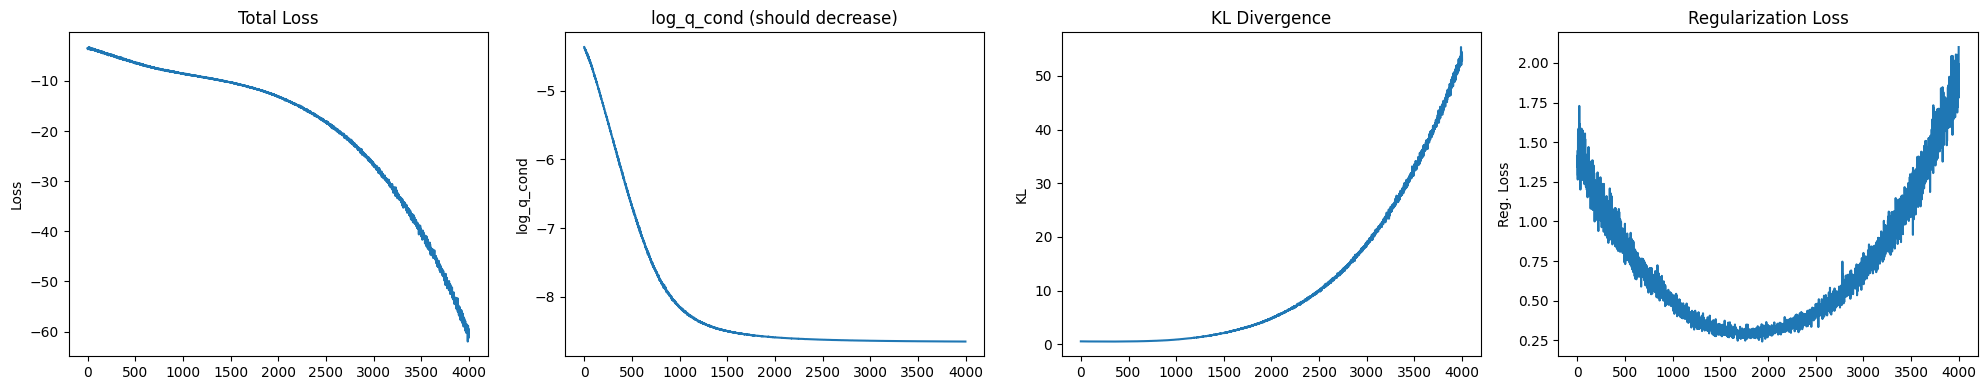

Training new model iteration 18...
Epoch 1: Loss=-4.3159, log_q=-4.7314,, reg. loss=0.9290, beta * KL=0.5135
Epoch 10: Loss=-5.4161, log_q=-5.6442,, reg. loss=0.7634, beta * KL=0.5353
Epoch 20: Loss=-6.6029, log_q=-6.6109,, reg. loss=0.6183, beta * KL=0.6103
Epoch 30: Loss=-7.6919, log_q=-7.3922,, reg. loss=0.5037, beta * KL=0.8034
Epoch 40: Loss=-8.7387, log_q=-7.9133,, reg. loss=0.3972, beta * KL=1.2227
Epoch 50: Loss=-9.8005, log_q=-8.2234,, reg. loss=0.3235, beta * KL=1.9007
Epoch 60: Loss=-10.9326, log_q=-8.3953,, reg. loss=0.2833, beta * KL=2.8206
Epoch 70: Loss=-12.2535, log_q=-8.4934,, reg. loss=0.2597, beta * KL=4.0198
Epoch 80: Loss=-13.8898, log_q=-8.5511,, reg. loss=0.2697, beta * KL=5.6084
Epoch 90: Loss=-16.0183, log_q=-8.5870,, reg. loss=0.3155, beta * KL=7.7468
Epoch 100: Loss=-18.7587, log_q=-8.6093,, reg. loss=0.4002, beta * KL=10.5496
Epoch 110: Loss=-22.2223, log_q=-8.6236,, reg. loss=0.4965, beta * KL=14.0952
Epoch 120: Loss=-26.3946, log_q=-8.6325,, reg. loss=0.63

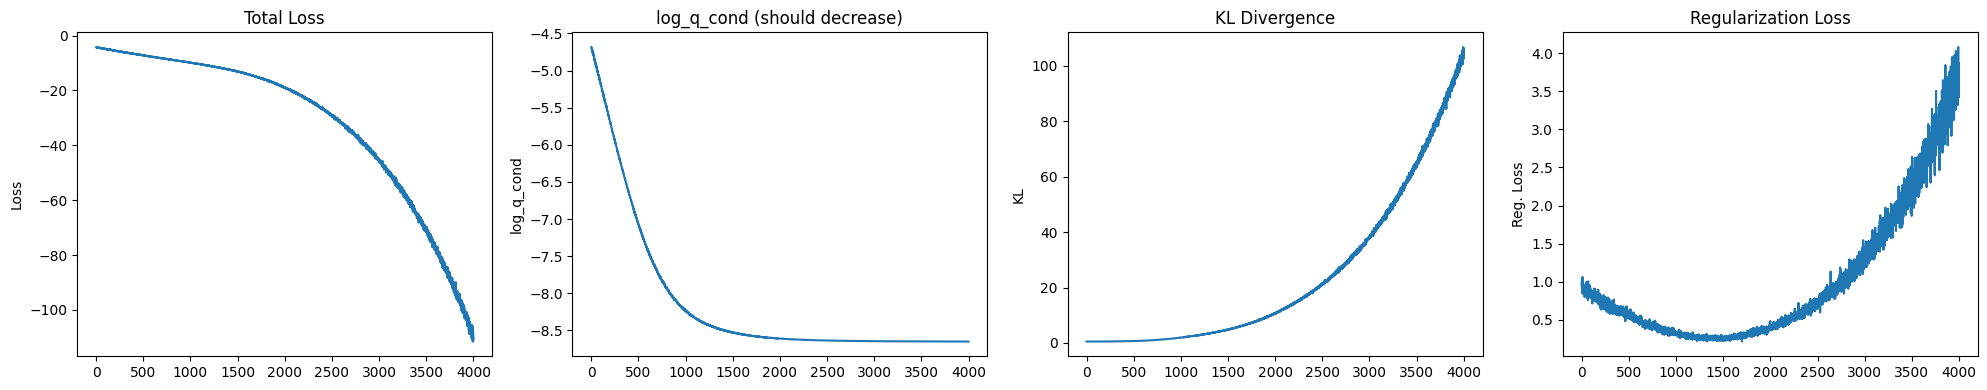

Training new model iteration 19...
Epoch 1: Loss=-4.5865, log_q=-5.0634,, reg. loss=0.9870, beta * KL=0.5100
Epoch 10: Loss=-5.5501, log_q=-5.8565,, reg. loss=0.8300, beta * KL=0.5237
Epoch 20: Loss=-6.5749, log_q=-6.6713,, reg. loss=0.6651, beta * KL=0.5687
Epoch 30: Loss=-7.5666, log_q=-7.3467,, reg. loss=0.4792, beta * KL=0.6991
Epoch 40: Loss=-8.4511, log_q=-7.8189,, reg. loss=0.3691, beta * KL=1.0013
Epoch 50: Loss=-9.3232, log_q=-8.1044,, reg. loss=0.3052, beta * KL=1.5239
Epoch 60: Loss=-10.2863, log_q=-8.2806,, reg. loss=0.2790, beta * KL=2.2847
Epoch 70: Loss=-11.4462, log_q=-8.3950,, reg. loss=0.2731, beta * KL=3.3243
Epoch 80: Loss=-12.8934, log_q=-8.4723,, reg. loss=0.2821, beta * KL=4.7031
Epoch 90: Loss=-14.7074, log_q=-8.5247,, reg. loss=0.3096, beta * KL=6.4923
Epoch 100: Loss=-16.9716, log_q=-8.5607,, reg. loss=0.3605, beta * KL=8.7714
Epoch 110: Loss=-19.7787, log_q=-8.5859,, reg. loss=0.4496, beta * KL=11.6425
Epoch 120: Loss=-23.2517, log_q=-8.6040,, reg. loss=0.555

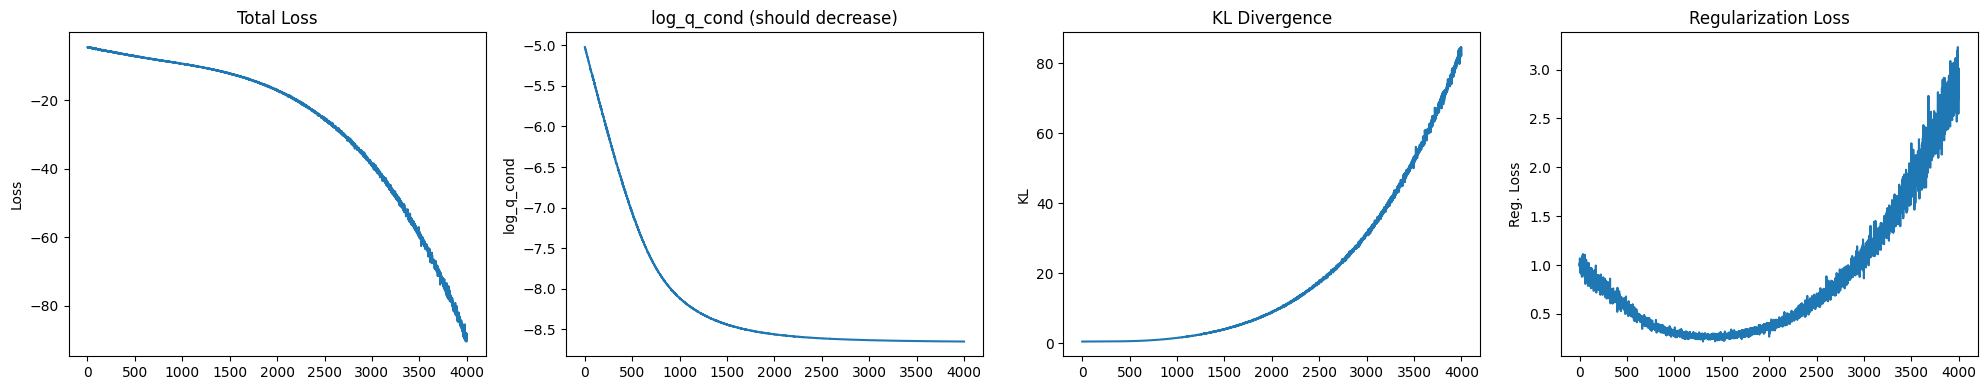

Training new model iteration 20...
Epoch 1: Loss=-4.2667, log_q=-4.4568,, reg. loss=0.7181, beta * KL=0.5280
Epoch 10: Loss=-5.2424, log_q=-5.3156,, reg. loss=0.6326, beta * KL=0.5594
Epoch 20: Loss=-6.3860, log_q=-6.2714,, reg. loss=0.5332, beta * KL=0.6478
Epoch 30: Loss=-7.5411, log_q=-7.1226,, reg. loss=0.4307, beta * KL=0.8492
Epoch 40: Loss=-8.5555, log_q=-7.7392,, reg. loss=0.3646, beta * KL=1.1808
Epoch 50: Loss=-9.4932, log_q=-8.1265,, reg. loss=0.3032, beta * KL=1.6699
Epoch 60: Loss=-10.4555, log_q=-8.3466,, reg. loss=0.2695, beta * KL=2.3783
Epoch 70: Loss=-11.5866, log_q=-8.4708,, reg. loss=0.2427, beta * KL=3.3586
Epoch 80: Loss=-12.9496, log_q=-8.5403,, reg. loss=0.2478, beta * KL=4.6571
Epoch 90: Loss=-14.7460, log_q=-8.5815,, reg. loss=0.2749, beta * KL=6.4395
Epoch 100: Loss=-16.9561, log_q=-8.6061,, reg. loss=0.3334, beta * KL=8.6834
Epoch 110: Loss=-19.6455, log_q=-8.6216,, reg. loss=0.4053, beta * KL=11.4292
Epoch 120: Loss=-22.8934, log_q=-8.6316,, reg. loss=0.507

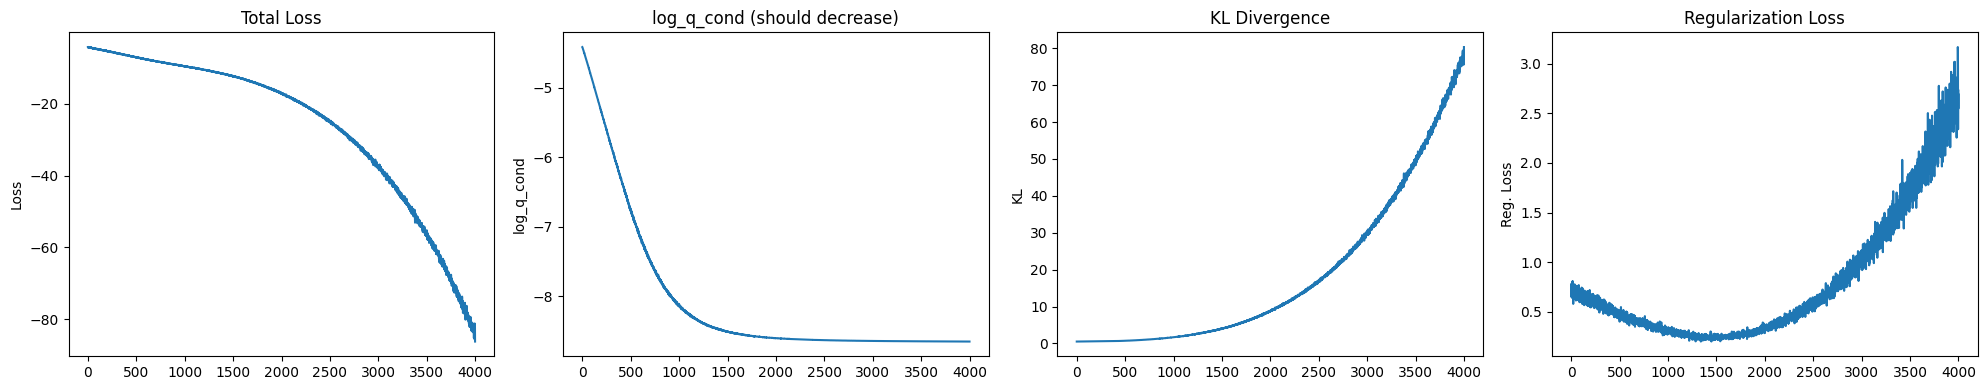

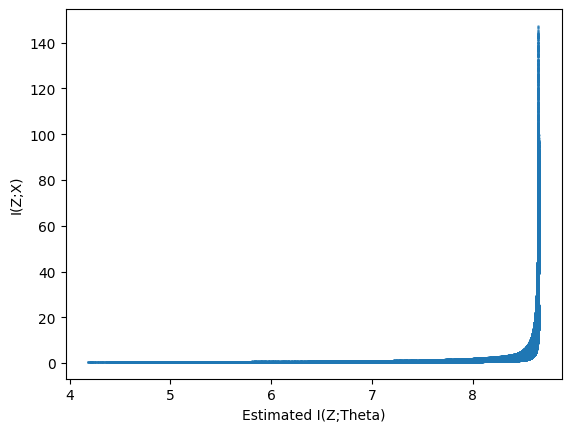

In [107]:
ba_bounds = []
i_z_x = []
for i in range(20):
    print(f"Training new model iteration {i+1}...")
    model_encoder=Compressor()
    model = IB(
        encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        # cond_prob_model=ConditionalKDE(1, 10),
        cond_prob_model=ConditionalNormalizingFlow(),
        beta = 1e0,
        reg_weight=1e0,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-5
    ).to(device)

    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=train_sims_data[:, -1],
        nepochs=200,
        batch_size=512,
        print_losses=True
        )
    assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

    ba_bounds = ba_bounds + model.log_prob_losses
    i_z_x = i_z_x + model.kl_losses

plt.scatter(-1*np.array(ba_bounds), i_z_x, alpha=0.5, s=1e0)
plt.xlabel("Estimated I(Z;Theta)")
plt.ylabel("I(Z;X)")
# plt.xlim([0, 25])
# plt.ylim([0, 10])
# plt.xlim([4, 6])
# plt.ylim([0.4, 0.6])
plt.show()

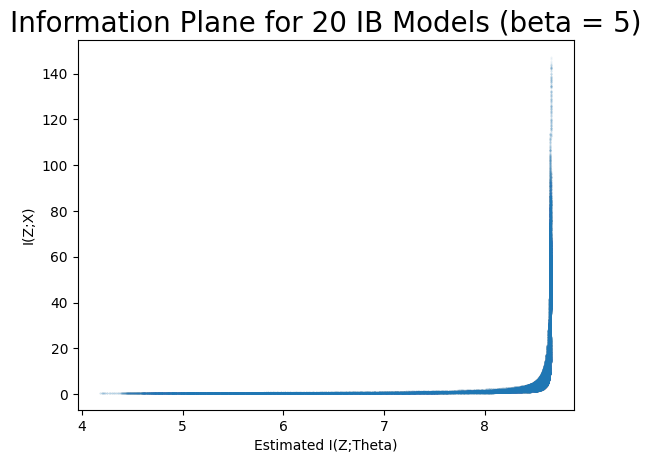

In [108]:
plt.scatter(-1*np.array(ba_bounds), i_z_x, alpha=0.1, s=1e-1)
plt.xlabel("Estimated I(Z;Theta)")
plt.ylabel("I(Z;X)")
# plt.xlim([0, 75])
# plt.ylim([0, 75])
# plt.xlim([0, 6])
# plt.ylim([0, 0.6])
plt.title('Information Plane for 20 IB Models (beta = 5)', fontsize=20)
plt.show()

In [122]:
np.save("ba_bounds.npy", -1*np.array(ba_bounds))
np.save("i_z_x.npy", i_z_x)

## Plotting the results to compare estimator std dev

18.806751 6.5168915


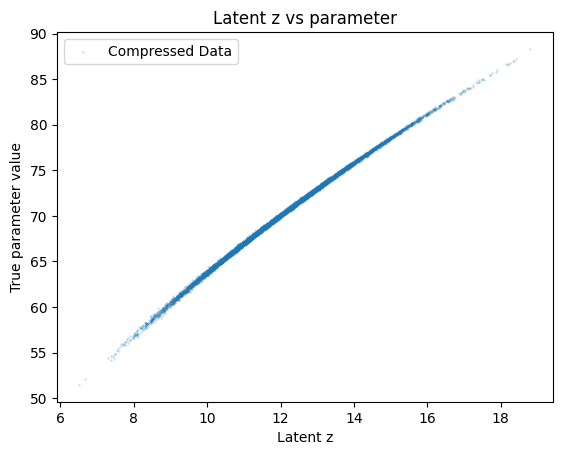

In [109]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
z = z.detach().cpu().numpy()

print(z.max(), z.min())

plt.scatter(z, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([110, 120])
plt.title('Latent z vs parameter')
plt.show()

In [79]:
# To check if the model collapsed: the standard deviations in m must match the priors
m.std(), l.std()

(tensor(1.1737, device='cuda:0', grad_fn=<StdBackward0>),
 tensor(0.9166, device='cuda:0', grad_fn=<StdBackward0>))

Dataset size: 10000, Number of bins: 11, Bin width: 0.15
Bin centers: [ 7.344035  8.681366 10.018696 11.356026 12.693356 14.030687 15.368017
 16.705347 18.042677 19.380009 20.717339]
Bin means: [54.81309127807617, 59.207977294921875, 63.84392547607422, 68.09778594970703, 72.11827087402344, 75.90458679199219, 79.5010757446289, 82.94800567626953, 86.30754852294922, nan, nan]
Bin stds: [0.4280789792537689, 0.2971937954425812, 0.21694518625736237, 0.17603176832199097, 0.16860850155353546, 0.1497456431388855, 0.137036994099617, 0.12913630902767181, 0.0, nan, nan]
Bin stds errors: [np.float64(0.21403948962688446), np.float64(0.03714922443032265), np.float64(0.011217968521735868), np.float64(0.006672466958631807), np.float64(0.007013189106718086), np.float64(0.008703788713535021), np.float64(0.01593022698463117), np.float64(0.032284077256917953), nan, nan, nan]


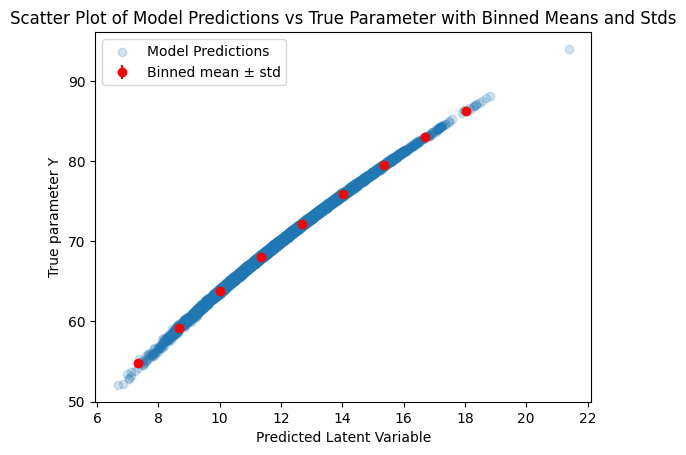

(np.float64(0.17203447765061478),
 array([0.42807898, 0.2971938 , 0.21694519, 0.17603177, 0.1686085 ,
        0.14974564, 0.13703699, 0.12913631]),
 array([0.21403949, 0.03714922, 0.01121797, 0.00667247, 0.00701319,
        0.00870379, 0.01593023, 0.03228408]))

In [110]:
sigma_beta, _, std, std_err = evaluate_posterior_covariance(model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])
sigma_beta, std, std_err

Dataset size: 10000, Number of bins: 11, Bin width: 0.01
Bin centers: [0.32627457 0.38669896 0.4471234  0.50754786 0.56797224 0.6283967
 0.68882114 0.7492455  0.80967    0.8700944  0.9305188 ]
Bin means: [54.75031661987305, 59.58809280395508, 64.06886291503906, 68.273193359375, 72.25735473632812, 75.9994125366211, 79.64383697509766, 83.0449447631836, 86.68346405029297, nan, nan]
Bin stds: [0.1628843992948532, 0.1598266065120697, 0.17513346672058105, 0.18040268123149872, 0.16353516280651093, 0.15440824627876282, 0.17083954811096191, 0.10574384778738022, 0.0, nan, nan]
Bin stds errors: [np.float64(0.05150856970800604), np.float64(0.01786915783870492), np.float64(0.008586624656648034), np.float64(0.0067895444735233505), np.float64(0.006778750591191626), np.float64(0.009260791200812543), np.float64(0.01910044214107283), np.float64(0.033439140755827795), nan, nan, nan]


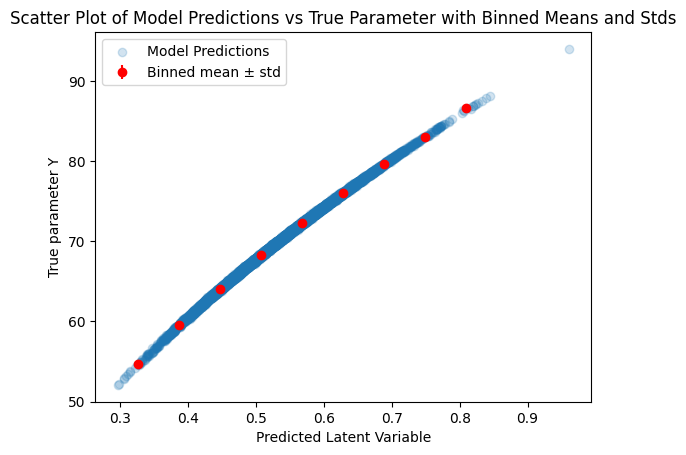

(np.float64(0.16845814020404695),
 array([0.1628844 , 0.15982661, 0.17513347, 0.18040268, 0.16353516,
        0.15440825, 0.17083955, 0.10574385]),
 array([0.05150857, 0.01786916, 0.00858662, 0.00678954, 0.00677875,
        0.00926079, 0.01910044, 0.03343914]))

In [33]:
def average_model(x):
    return x.mean(dim=1)

sigma_beta_true, _, std_true, std_err_true = evaluate_posterior_covariance(average_model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])

sigma_beta_true, std_true, std_err_true

Dataset size: 10000, Number of bins: 11, Bin width: 0.00
Bin centers: [0.738636   0.7486396  0.75864303 0.7686465  0.77865005 0.7886535
 0.79865706 0.8086605  0.818664   0.8286675  0.83867097]
Bin means: [nan, 86.82498931884766, 82.75145721435547, 78.54656219482422, 74.33207702636719, 70.44176483154297, 66.64311981201172, 63.20269775390625, 59.80452346801758, 56.30775833129883, 53.65597915649414]
Bin stds: [nan, 0.19041436910629272, 0.42273327708244324, 0.5279780626296997, 0.4659232199192047, 0.4899803102016449, 0.4766843318939209, 0.41772016882896423, 0.3382565975189209, 0.4566071033477783, 0.1536816656589508]
Bin stds errors: [nan, np.float64(0.09520718455314636), np.float64(0.0945260343907597), np.float64(0.040979045087145255), np.float64(0.02206210388736645), np.float64(0.01868032419921925), np.float64(0.02166746963154186), np.float64(0.0273072216933354), np.float64(0.04295863084355528), np.float64(0.13181111701586756), np.float64(0.0768408328294754)]


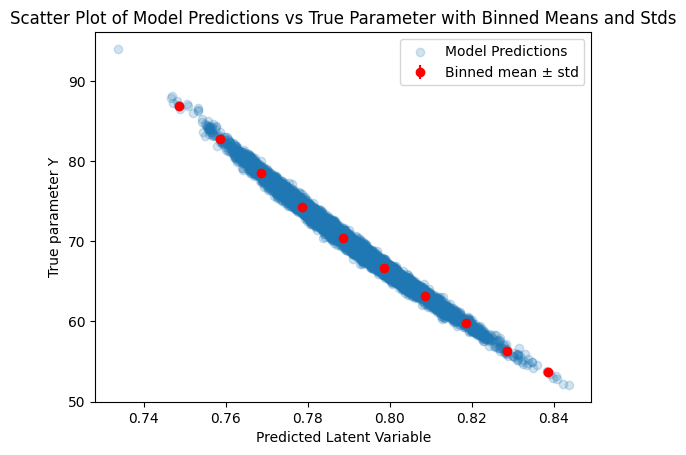

(np.float64(0.45653704770835146),
 array([0.19041437, 0.42273328, 0.52797806, 0.46592322, 0.48998031,
        0.47668433, 0.41772017, 0.3382566 , 0.4566071 , 0.15368167]),
 array([0.09520718, 0.09452603, 0.04097905, 0.0220621 , 0.01868032,
        0.02166747, 0.02730722, 0.04295863, 0.13181112, 0.07684083]))

In [34]:
def true_flux_model(x):
    flux = 10**(-0.4*x)
    return flux.mean(dim=1)

sigma_beta_true, _, std_true, std_err_true = evaluate_posterior_covariance(true_flux_model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])

sigma_beta_true, std_true, std_err_true

## Posterior comparison

In [111]:
SELECT_PERCENT = 5e-3

Creating sample: 1 of 1
Compressed obs: 11.960393905639648
Selected 289 samples from test set with compressed value close to observed compressed value.


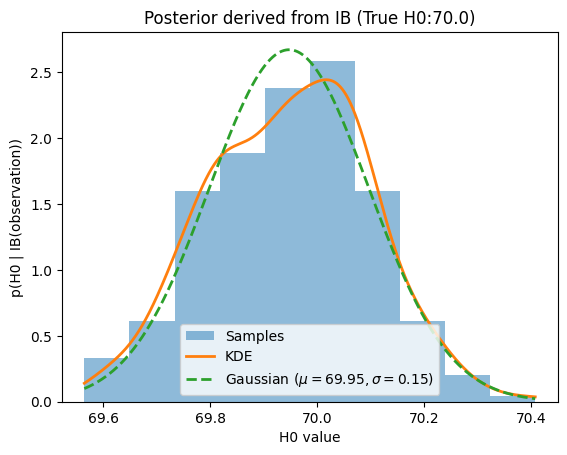

In [112]:
true_h0 = 70.0
# true_h0 = test_sims_data[0, -1].item()
_, data_obs, _, _ = create_synthetic_supernovae_dataset(n_samples=1, h0s=[true_h0])
data_obs = torch.tensor(data_obs, dtype=torch.float32).to(device)

# data_obs = test_sims_data[0:1, :DATAPOINT_SIZE]
compressed_test = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu().numpy()

compressed_obs = model(data_obs).detach().cpu().numpy()

print("Compressed obs:", compressed_obs.item())

mask = abs(compressed_test[:, 0] - compressed_obs.item())/(abs(compressed_obs.item()) + 1e-8) < SELECT_PERCENT
selected_h0 = test_sims_data[mask, -1].cpu().numpy()
print(f"Selected {len(selected_h0)} samples from test set with compressed value close to observed compressed value.")

mu, sigma = norm.fit(selected_h0)

x = np.linspace(selected_h0.min(), selected_h0.max(), 1000)

kde = gaussian_kde(selected_h0)

plt.hist(selected_h0, density=True, alpha=0.5, label='Samples')
plt.plot(x, kde(x), lw=2, label='KDE')
plt.plot(x, norm.pdf(x, mu, sigma), '--', lw=2,
         label=fr'Gaussian ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')
plt.xlabel('H0 value')
plt.ylabel('p(H0 | IB(observation))')
plt.title(f'Posterior derived from IB (True H0:{true_h0})')
plt.legend()
plt.show()

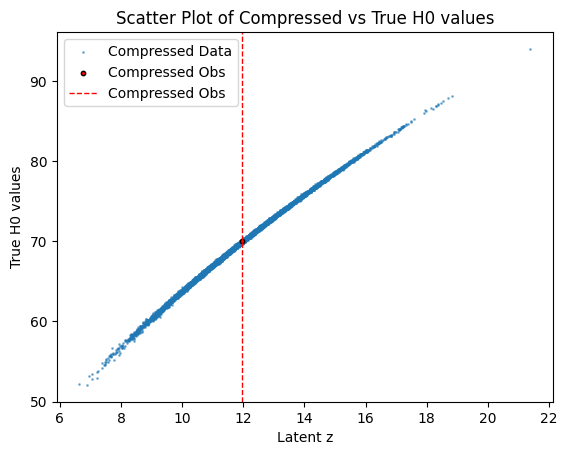

In [113]:
plt.scatter(compressed_test[:, 0], test_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1, label='Compressed Data')
plt.scatter(compressed_obs[0, 0], true_h0, color='red', label='Compressed Obs', s=10, edgecolor='black')
plt.axvline(compressed_obs[0, 0], color='red', linestyle='dashed', linewidth=1, label='Compressed Obs')
plt.xlabel('Latent z')
plt.ylabel('True H0 values')
plt.title('Scatter Plot of Compressed vs True H0 values')
plt.legend()
plt.show()

### MOPED Compression

In [114]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]

fid_vals = np.array([75.0])

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)
MOPED Fisher information: [[0.0004]]


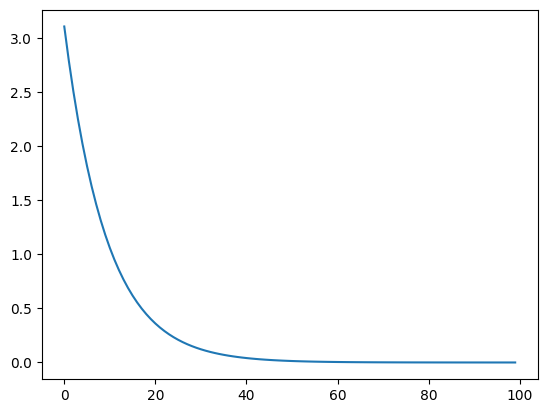

In [115]:
b, F, d = moped(fid_vals, cov, estimator_given_theta)
# print("MOPED compressed value:", b)
print("MOPED Fisher information:", 1/F)
plt.plot(b.T)
plt.show()

In [116]:
moped_d_obs = data_obs.detach().cpu().numpy()[0, :DATAPOINT_SIZE]
# moped_d_obs = 10**(-0.4*moped_d_obs)
moped_compressed = moped_d_obs @ b.T
moped_compressed

array([87.14785135])

In [117]:
# moped_test = 10**(-0.4*test_sims_data[:, :DATAPOINT_SIZE].detach().cpu().numpy()) @ b.T
moped_test = test_sims_data[:, :DATAPOINT_SIZE].detach().cpu().numpy() @ b.T
mask_moped = abs(moped_test[:, 0] - moped_compressed[0])/(abs(moped_compressed[0]) + 1e-8) < SELECT_PERCENT

selected_h0_moped = test_sims_data[mask_moped, -1].cpu().numpy()
print(f"Selected {len(selected_h0_moped)} samples from test set with MOPED compressed value close to observed MOPED compressed value.")

Selected 276 samples from test set with MOPED compressed value close to observed MOPED compressed value.


In [118]:
mask_moped

array([False, False, False, ..., False,  True, False], shape=(10000,))

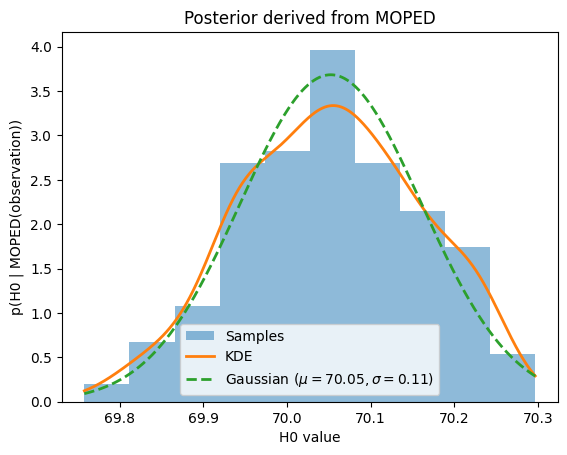

In [119]:
mu, sigma = norm.fit(selected_h0_moped)

x = np.linspace(selected_h0_moped.min(), selected_h0_moped.max(), 1000)

kde = gaussian_kde(selected_h0_moped)

plt.hist(selected_h0_moped, density=True, alpha=0.5, label='Samples')
plt.plot(x, kde(x), lw=2, label='KDE')
plt.plot(x, norm.pdf(x, mu, sigma), '--', lw=2,
         label=fr'Gaussian ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')
plt.xlabel('H0 value')
plt.ylabel('p(H0 | MOPED(observation))')
plt.title('Posterior derived from MOPED')
plt.legend()
plt.show()

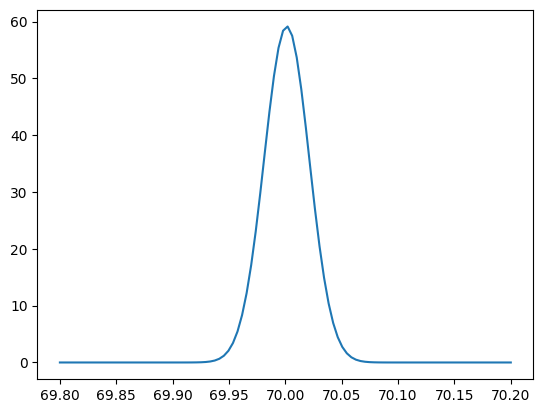

In [120]:
h0s = np.linspace(69.8, 70.2, 100)
p_theta = norm.pdf(h0s, loc=70, scale=DATA_VARIANCE_SCALE)
likelihood = kde(h0s) * p_theta

plt.plot(h0s, likelihood, label='Posterior from IB')

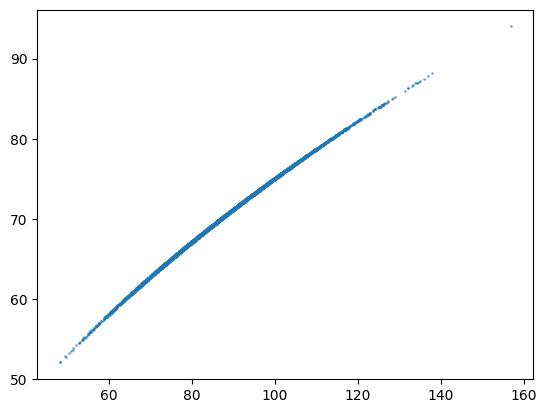

In [121]:
plt.scatter(moped_test[:, 0], test_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1, label='MOPED Compressed Data')
plt.show()